# NASA C-MAPSS FD003 — ML Pipeline (일반실험 + Optuna, CPU/GPU)

**[FD003 No-Clustering]** 단일 운전조건(Sea Level) → 전체 MinMax 정규화  
파이프라인 직접 실행 → 일반 ML 실험 / Optuna 튜닝, CPU / GPU 자동 전환

> 고장 모드: HPC + Fan 열화 2개 | 운전조건: 1개 (클러스터링 불필요)


## 0. 환경 & 라이브러리

In [ ]:
import os, warnings, json, platform, subprocess, time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.ndimage import gaussian_filter1d
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split, GroupKFold, learning_curve
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
import lightgbm as lgb
import optuna
from optuna.samplers import TPESampler
import joblib

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── 한글 폰트 ──────────────────────────────────────────────────────────────
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

# ── GPU 자동 감지 ──────────────────────────────────────────────────────────
try:
    GPU_AVAILABLE = subprocess.run(['nvidia-smi'], capture_output=True).returncode == 0
except:
    GPU_AVAILABLE = False
XGB_DEVICE = 'cuda' if GPU_AVAILABLE else 'cpu'
LGB_DEVICE  = 'gpu'  if GPU_AVAILABLE else 'cpu'
print(f'✅ 라이브러리 로드 완료')
print(f'   GPU: {GPU_AVAILABLE} | XGB={XGB_DEVICE} | LGB={LGB_DEVICE}')


✅ 라이브러리 로드 완료
   GPU: True | XGB=cuda | LGB=gpu


In [ ]:
# ── 컬럼 정의 ─────────────────────────────────────────────────────────────
RAW_COLS    = ['unit','cycle','op1','op2','op3'] + [f's{i}' for i in range(1, 22)]
RENAME_MAP  = {
    'unit':'unit_nr', 'cycle':'time_cycles',
    'op1':'setting_1', 'op2':'setting_2', 'op3':'setting_3',
    **{f's{i}': f's_{i}' for i in range(1, 22)}
}
SENSOR_COLS = [f's_{i}' for i in range(1, 22)]
OP_COLS     = ['setting_1','setting_2','setting_3']
ID_COLS     = ['unit_nr','time_cycles']
print('✅ 컬럼 정의 완료')


✅ 컬럼 정의 완료


## 1. CONFIG — 파이프라인 파라미터

In [ ]:
# ============================================================
# 🔧 CONFIG — 모든 파이프라인 파라미터를 여기서 조절
# ============================================================
CONFIG = {
    # 센서 추가 수동 제거 (예: ['s_5','s_9']). 빈 리스트면 자동제거만 적용
    'manual_remove_sensors': ['s_1', 's_5', 's_6','s_16', 's_18', 's_19'],

    # RUL Cap (120 / 125 / 130)
    'rul_cap': 130,

    # Gaussian sigma (None=skip / 1 / 2 / 3)
    'gaussian_sigma': None,

    # 정규화 방식 ('minmax' / 'standard')
    'normalize': 'standard',

    # ── 시계열 파생변수 (원하는 만큼 리스트로) ──
     'rolling_means':[5, 50, 120], # [100] , [5, 40, 100] , [70] , [5, 50, 120]
    'diffs':        [10, 50, 100],  # [60] , [1, 50, 70] , [70] , [10, 50, 100]
    'lags':         [1, 50, 100],  # [70] , [1, 50, 100] , [40] , [1, 50, 100]
    'rolling_stds': [10, 50, 100],  # [60] , [10, 50, 100] , [70] , [10, 50, 100]
    'emas':         [5, 50, 120],  # [70] , [1, 20, 100] , [40] , [5, 50, 120]
}

# 슬라이딩 윈도우 (DL 용)
WINDOW_SIZE = 30
STEP        = 1

# 클러스터 / 기타 상수
N_CLUSTERS = 6
CONST_THR  = 1e-3
RANDOM_STATE = 42
VALID_RATIO  = 0.2

print('✅ CONFIG 로드 완료')
for k,v in CONFIG.items():
    print(f'   {k:22s}: {v}')


✅ CONFIG 로드 완료
   manual_remove_sensors : ['s_1', 's_5', 's_6', 's_16', 's_18', 's_19']
   rul_cap               : 130
   gaussian_sigma        : None
   normalize             : standard
   lags                  : [1, 50, 100]
   diffs                 : [10, 50, 100]
   rolling_means         : [5, 50, 120]
   rolling_stds          : [10, 50, 100]
   emas                  : [5, 50, 120]


## 2. 데이터 로딩

In [ ]:
DATA_DIR = 'CMAPSSData'
for c in ['../../CMAPSSData', './CMAPSSData', '../CMAPSSData']:
    if os.path.exists(os.path.join(c, 'train_FD004.txt')):
        DATA_DIR = c; break

kw = dict(sep=r'\s+', header=None, names=RAW_COLS, engine='python')
train_raw = pd.read_csv(f'{DATA_DIR}/train_FD004.txt', **kw)
test_raw  = pd.read_csv(f'{DATA_DIR}/test_FD004.txt',  **kw)
rul_df    = pd.read_csv(f'{DATA_DIR}/RUL_FD004.txt',
                        sep=r'\s+', header=None, names=['RUL'], engine='python')
train_raw.rename(columns=RENAME_MAP, inplace=True)
test_raw.rename( columns=RENAME_MAP, inplace=True)

print(f'✅ FD003 로딩 완료')
print(f'   Train : {train_raw.shape}  |  엔진 {train_raw["unit_nr"].nunique()}대')
print(f'   Test  : {test_raw.shape}   |  엔진 {test_raw["unit_nr"].nunique()}대')
print(f'   RUL   : {rul_df.shape}')


✅ FD003 로딩 완료
   Train : (61249, 26)  |  엔진 249대
   Test  : (41214, 26)   |  엔진 248대
   RUL   : (248, 1)


## 3. 파이프라인 함수 정의

In [ ]:
# ============================================================
# 🔧 파이프라인 함수 (FD003 No-Clustering 전용)
# ============================================================

def filter_useful_sensors(train_df, sensor_cols, manual_remove, const_thr=None):
    # 1. 제거 대상: 사용자가 입력한 리스트 그대로 사용 (중복 제거 및 정렬만 수행)
    remove = sorted(list(set(manual_remove or [])))
    
    # 2. 유지 대상: 전체 21개 센서 중 위 리스트에 없는 것만 남김
    useful = [s for s in sensor_cols if s not in remove]
    
    # s_1, s_2 순서대로 예쁘게 정렬
    useful = sorted(useful, key=lambda x: int(x.split('_')[1]) if '_' in x else x)
    
    return useful, remove


def add_piecewise_rul(df, cap):
    """엔진별 RUL 계산 후 cap 적용"""
    df  = df.copy()
    mc  = df.groupby('unit_nr')['time_cycles'].max().rename('max_c')
    df  = df.join(mc, on='unit_nr')
    df['RUL_raw'] = df['max_c'] - df['time_cycles']
    df['RUL']     = df['RUL_raw'].clip(upper=cap)
    return df.drop('max_c', axis=1)


def apply_gaussian_by_unit(df, features, sigma):
    """엔진 단위 가우시안 스무딩"""
    df = df.copy().sort_values(['unit_nr', 'time_cycles']).reset_index(drop=True)
    def _smooth(s):
        return gaussian_filter1d(s.values.astype(np.float32), sigma=sigma, mode='nearest') if len(s) > 1 else s.values
    for col in features:
        df[col] = df.groupby('unit_nr')[col].transform(_smooth)
    return df


def split_by_unit(train_df, valid_ratio=VALID_RATIO, random_state=RANDOM_STATE):
    """엔진 단위 random split"""
    units = train_df['unit_nr'].unique()
    sub_u, val_u = train_test_split(units, test_size=valid_ratio, random_state=random_state)
    sub = train_df[train_df['unit_nr'].isin(sub_u)].copy().reset_index(drop=True)
    val = train_df[train_df['unit_nr'].isin(val_u)].copy().reset_index(drop=True)
    return sub, val, sub_u, val_u


def normalize_global(sub, val, test, features, method):
    """전체 정규화 (sub-train 기준 fit) — FD003은 단일 운전조건이므로 전체 적용"""
    ScalerCls = {'minmax': MinMaxScaler, 'standard': StandardScaler}[method]
    scaler    = ScalerCls()
    sub  = sub.copy();  val  = val.copy();  test = test.copy()
    sub[features]  = scaler.fit_transform(sub[features])
    val[features]  = scaler.transform(val[features])
    test[features] = scaler.transform(test[features])
    return sub, val, test, scaler


def add_temporal_features(df, sensor_cols, lags, diffs, rolls, roll_stds, emas):
    """엔진 단위 시계열 파생변수 생성"""
    df = df.copy().sort_values(['unit_nr', 'time_cycles'])
    for s in sensor_cols:
        grp = df.groupby('unit_nr')[s]
        for lag in (lags or []):
            df[f'{s}_lag{lag}']     = grp.shift(lag)
        for d in (diffs or []):
            df[f'{s}_diff{d}']      = grp.diff(d)
        for r in (rolls or []):
            df[f'{s}_roll{r}']      = grp.transform(lambda x: x.rolling(r, min_periods=1).mean())
        for r in (roll_stds or []):
            df[f'{s}_rollstd{r}']   = grp.transform(lambda x: x.rolling(r, min_periods=1).std().fillna(0))
        for span in (emas or []):
            df[f'{s}_ema{span}']    = grp.transform(lambda x: x.ewm(span=span, adjust=False).mean())
    return df.fillna(0)


def run_pipeline(train_raw, test_raw, cfg):
    """FD003 전처리 파이프라인 (No-Clustering)"""
    # 1. 센서 필터링
    useful, removed = filter_useful_sensors(train_raw, SENSOR_COLS, cfg['manual_remove_sensors'])
    print(f'[1] 센서 필터링: 유지 {len(useful)}개 / 제거 {len(removed)}개  {removed}')

    keep = ID_COLS + OP_COLS + useful
    tr1  = train_raw[keep].copy()
    te1  = test_raw[keep].copy()

    # 2. Piecewise RUL
    tr2 = add_piecewise_rul(tr1, cap=cfg['rul_cap'])
    te2 = te1.copy()
    print(f'[2] Piecewise RUL 적용 (cap={cfg["rul_cap"]})')

    # 3. Gaussian Smoothing
    if cfg.get('gaussian_sigma') and cfg['gaussian_sigma'] > 0:
        tr3 = apply_gaussian_by_unit(tr2, useful, sigma=cfg['gaussian_sigma'])
        te3 = apply_gaussian_by_unit(te2, useful, sigma=cfg['gaussian_sigma'])
        print(f'[3] Gaussian σ={cfg["gaussian_sigma"]} 적용')
    else:
        tr3, te3 = tr2, te2
        print('[3] Gaussian skip')

    # 4. Split
    sub4, val4, sub_units, val_units = split_by_unit(tr3, VALID_RATIO, RANDOM_STATE)
    test4 = te3.copy()
    print(f'[4] 데이터 분할: sub={len(sub_units)}대 / val={len(val_units)}대')

    # 5. 정규화 (전체 MinMax — FD003은 단일 운전조건)
    sub5, val5, test5, scaler = normalize_global(sub4, val4, test4, useful, cfg['normalize'])
    print(f'[5] 전체 정규화 완료 ({cfg["normalize"]})')

    # 6. 시계열 파생변수
    sub6  = add_temporal_features(sub5,  useful, cfg['lags'], cfg['diffs'],
                                   cfg['rolling_means'], cfg['rolling_stds'], cfg['emas'])
    val6  = add_temporal_features(val5,  useful, cfg['lags'], cfg['diffs'],
                                   cfg['rolling_means'], cfg['rolling_stds'], cfg['emas'])
    test6 = add_temporal_features(test5, useful, cfg['lags'], cfg['diffs'],
                                   cfg['rolling_means'], cfg['rolling_stds'], cfg['emas'])

    EXCLUDE    = set(ID_COLS + OP_COLS + ['RUL', 'RUL_raw'])
    ml_features = [c for c in sub6.columns if c not in EXCLUDE]
    print(f'[6] 파생변수 생성 완료 (ML features={len(ml_features)}개)')

    return {
        'subtrain_ml': sub6, 'valid_ml': val6, 'test_ml': test6,
        'ml_features': ml_features, 'scaler': scaler,
    }

print('✅ 파이프라인 함수 정의 완료')


✅ 파이프라인 함수 정의 완료


## 4. 파이프라인 실행

In [ ]:
data        = run_pipeline(train_raw, test_raw, CONFIG)

train_ml    = data['subtrain_ml'].sort_values(['unit_nr','time_cycles']).reset_index(drop=True)
valid_ml    = data['valid_ml'   ].sort_values(['unit_nr','time_cycles']).reset_index(drop=True)
test_ml     = data['test_ml'    ].sort_values(['unit_nr','time_cycles']).reset_index(drop=True)
ML_FEATURES = data['ml_features']
scaler_obj  = data['scaler']

# Test 평가: 엔진별 마지막 사이클만
test_last   = test_ml.groupby('unit_nr').last().reset_index()
X_train, y_train = train_ml[ML_FEATURES], train_ml['RUL']
X_val,   y_val   = valid_ml[ML_FEATURES], valid_ml['RUL']
X_test           = test_last[ML_FEATURES]
y_test           = rul_df['RUL'].values

print(f'\n[실행 결과]')
print(f'  Sub-train : {train_ml.shape}')
print(f'  Validation: {valid_ml.shape}')
print(f'  Test      : {test_ml.shape}')
print(f'  ML 피처 수: {len(ML_FEATURES)}개')
print(f'  주요 피처 : {ML_FEATURES[:8]}...')


[1] 센서 필터링: 유지 15개 / 제거 6개  ['s_1', 's_16', 's_18', 's_19', 's_5', 's_6']
[2] Piecewise RUL 적용 (cap=130)
[3] Gaussian skip
[4] 데이터 분할: sub=199대 / val=50대
[5] 전체 정규화 완료 (standard)
[6] 파생변수 생성 완료 (ML features=240개)

[실행 결과]
  Sub-train : (49294, 247)
  Validation: (11955, 247)
  Test      : (41214, 245)
  ML 피처 수: 240개
  주요 피처 : ['s_2', 's_3', 's_4', 's_7', 's_8', 's_9', 's_10', 's_11']...


## 5. 평가 유틸 & 시각화 함수

In [ ]:
# ── NASA Score ────────────────────────────────────────────────────────────
def calculate_nasa_score(y_true, y_pred):
    d     = np.asarray(y_pred, dtype=float) - np.asarray(y_true, dtype=float)
    score = np.where(d < 0, np.exp(-d / 13) - 1, np.exp(d / 10) - 1)
    return float(np.sum(score))

def get_metrics(y_true, y_pred, cap=CONFIG['rul_cap']):
    pred = np.clip(np.asarray(y_pred, dtype=float), 0, cap)
    return {
        'RMSE'      : float(np.sqrt(mean_squared_error(y_true, pred))),
        'MAE'       : float(mean_absolute_error(y_true, pred)),
        'R2'        : float(r2_score(y_true, pred)),
        'NASA_Score': calculate_nasa_score(y_true, pred),
    }

# ── 통합 시각화 함수 (2×3 — 6 plots) ───────────────────────────────────────
def evaluate_full_pipeline(model, model_name, is_tree=False, is_boosting=False, eval_results=None):
    pred_train = model.predict(X_train)
    pred_val   = model.predict(X_val)
    pred_test  = model.predict(X_test)

    res = {
        'Train': get_metrics(y_train, pred_train),
        'Valid': get_metrics(y_val,   pred_val),
        'Test' : get_metrics(y_test,  pred_test),
    }

    print(f"\n{'='*55}\n 🏆 {model_name} 평가 결과\n{'='*55}")
    for split, m in res.items():
        print(f" [{split:5s}] RMSE={m['RMSE']:.4f} | MAE={m['MAE']:.4f} | "
              f"R2={m['R2']:.4f} | NASA={m['NASA_Score']:.1f}")

    fig, axes = plt.subplots(2, 3, figsize=(22, 12))
    fig.suptitle(f'{model_name} — 전체 평가 (FD003)', fontsize=14, fontweight='bold')
    plt.subplots_adjust(hspace=0.35)

    # 1. Learning / Loss Curve
    ax1 = axes[0, 0]
    if is_boosting and eval_results:
        ax1.plot(eval_results['train'], label='Train RMSE')
        ax1.plot(eval_results['valid'], label='Valid RMSE')
        ax1.set_xlabel('Iterations')
    else:
        sizes, t_sc, v_sc = learning_curve(
            model, X_train, y_train, cv=3, scoring='neg_root_mean_squared_error',
            train_sizes=np.linspace(0.2, 1.0, 5))
        ax1.plot(sizes, -np.mean(t_sc, axis=1), 'o-', label='Train RMSE')
        ax1.plot(sizes, -np.mean(v_sc, axis=1), 'o-', label='Valid RMSE')
        ax1.set_xlabel('Training Samples')
    ax1.set_title('① Learning / Loss Curve'); ax1.legend(); ax1.grid(True)

    # 2. Residual Plot (Validation)
    axes[0, 1].scatter(pred_val, y_val - pred_val, alpha=0.3, color='orange', s=8)
    axes[0, 1].axhline(0, color='red', ls='--')
    axes[0, 1].set_title('② Residual Plot (Validation)')
    axes[0, 1].set_xlabel('Predicted'); axes[0, 1].set_ylabel('Residual')

    # 3. Feature Importance / Coefficient Top-15
    ax3 = axes[0, 2]
    imp = model.feature_importances_ if is_tree else np.abs(model.coef_)
    idx = np.argsort(imp)[-15:]
    ax3.barh(range(15), imp[idx], color='teal')
    ax3.set_yticks(range(15))
    ax3.set_yticklabels(np.array(ML_FEATURES)[idx], fontsize=8)
    ax3.set_title('③ Top-15 Feature Importance')

    # 4. Target vs Prediction Distribution (Validation)
    sns.kdeplot(y_val,   label='Actual', ax=axes[1, 0], fill=True)
    sns.kdeplot(pred_val,label='Pred',   ax=axes[1, 0], fill=True)
    axes[1, 0].set_title('④ RUL 분포 비교 (Validation)'); axes[1, 0].legend()

    # 5. Feature Weight Histogram
    axes[1, 1].hist(imp, bins=30, color='purple', alpha=0.7)
    axes[1, 1].set_title('⑤ Feature Weight Histogram')

    # 6. Test — Actual vs Predicted Line
    ax6 = axes[1, 2]
    ax6.plot(y_test,    label='Actual RUL',    color='black', lw=1.5)
    ax6.plot(pred_test, label='Predicted RUL', color='red', ls='--', alpha=0.8)
    ax6.set_title('⑥ Test: Actual vs Predicted')
    ax6.set_xlabel('Engine Index'); ax6.set_ylabel('RUL')
    ax6.legend(); ax6.grid(True)

    plt.tight_layout()
    plt.show()
    return res

print('✅ 평가 & 시각화 함수 정의 완료')


✅ ML 라이브러리 로드 완료


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import learning_curve

# --- 1. 데이터 준비 (X, y 분리 및 Test 세트 구성) ---
X_train, y_train = train_ml[ML_FEATURES], train_ml['RUL']
X_val, y_val = valid_ml[ML_FEATURES], valid_ml['RUL']

# Test 평가는 각 엔진의 '마지막 사이클'만 추출하여 수행
test_last = test_ml.groupby('unit_nr').last().reset_index()
X_test = test_last[ML_FEATURES]
y_test = rul_df['RUL'].values 

# --- 2. NASA Score 함수 ---
def calculate_nasa_score(y_true, y_pred):
    d = y_pred - y_true
    score = np.where(d < 0, np.exp(-d / 13) - 1, np.exp(d / 10) - 1)
    return np.sum(score)

# --- 3. 통합 시각화 함수 (6개 그래프) ---
def evaluate_full_pipeline(model, model_name, is_tree=False, is_boosting=False, eval_results=None):
    # 예측
    pred_train = model.predict(X_train)
    pred_val = model.predict(X_val)
    pred_test = model.predict(X_test)
    
    # 지표 계산
    results = {
        'Train': [np.sqrt(mean_squared_error(y_train, pred_train)), calculate_nasa_score(y_train, pred_train)],
        'Valid': [np.sqrt(mean_squared_error(y_val, pred_val)), calculate_nasa_score(y_val, pred_val)],
        'Test':  [np.sqrt(mean_squared_error(y_test, pred_test)), calculate_nasa_score(y_test, pred_test)]
    }
    
    print(f"\n" + "="*50 + f"\n 🏆 {model_name} 최종 평가 결과 \n" + "="*50)
    for k, v in results.items():
        print(f" [{k}] RMSE: {v[0]:.4f} | NASA Score: {v[1]:.2f}")
    
    # 시각화 (2x3)
    fig, axes = plt.subplots(2, 3, figsize=(22, 12))
    plt.subplots_adjust(hspace=0.3)
    
    # (1) Learning Curve
    ax1 = axes[0, 0]
    if is_boosting and eval_results:
        ax1.plot(eval_results['train'], label='Train RMSE')
        ax1.plot(eval_results['valid'], label='Valid RMSE')
        ax1.set_xlabel('Iterations')
    else:
        sizes, t_scores, v_scores = learning_curve(model, X_train, y_train, cv=3, scoring='neg_root_mean_squared_error')
        ax1.plot(sizes, -np.mean(t_scores, axis=1), 'o-', label='Train RMSE')
        ax1.plot(sizes, -np.mean(v_scores, axis=1), 'o-', label='Valid RMSE')
        ax1.set_xlabel('Training Samples')
    ax1.set_title('1. Learning/Loss Curve')
    ax1.legend(); ax1.grid(True)

    # (2) Residual Plot (Validation)
    axes[0, 1].scatter(pred_val, y_val - pred_val, alpha=0.3, color='orange')
    axes[0, 1].axhline(0, color='red', linestyle='--')
    axes[0, 1].set_title('2. Residual Plot (Validation)')

    # (3) Feature Importance
    ax3 = axes[0, 2]
    imp = model.feature_importances_ if is_tree else np.abs(model.coef_)
    idx = np.argsort(imp)[-15:]
    ax3.barh(range(15), imp[idx], color='teal')
    ax3.set_yticks(range(15)); ax3.set_yticklabels(np.array(ML_FEATURES)[idx])
    ax3.set_title('3. Top 15 Features')

    # (4) Target vs Prediction Distribution (Validation)
    sns.kdeplot(y_val, label='Actual', ax=axes[1, 0], fill=True)
    sns.kdeplot(pred_val, label='Pred', ax=axes[1, 0], fill=True)
    axes[1, 0].set_title('4. Target Distribution (Val)'); axes[1, 0].legend()

    # (5) Weight/Importance Histogram
    axes[1, 1].hist(imp, bins=30, color='purple', alpha=0.7)
    axes[1, 1].set_title('5. Feature Weight Histogram')

    # (6) [NEW] Test Actual vs Prediction Line Graph
    ax6 = axes[1, 2]
    ax6.plot(y_test, label='Actual RUL', color='black', linewidth=1.5)
    ax6.plot(pred_test, label='Predicted RUL', color='red', linestyle='--', alpha=0.8)
    ax6.set_title('6. Test: Actual vs Predicted Line Graph')
    ax6.set_xlabel('Engine Unit (Index)'); ax6.set_ylabel('RUL')
    ax6.legend(); ax6.grid(True)
    
    plt.show()

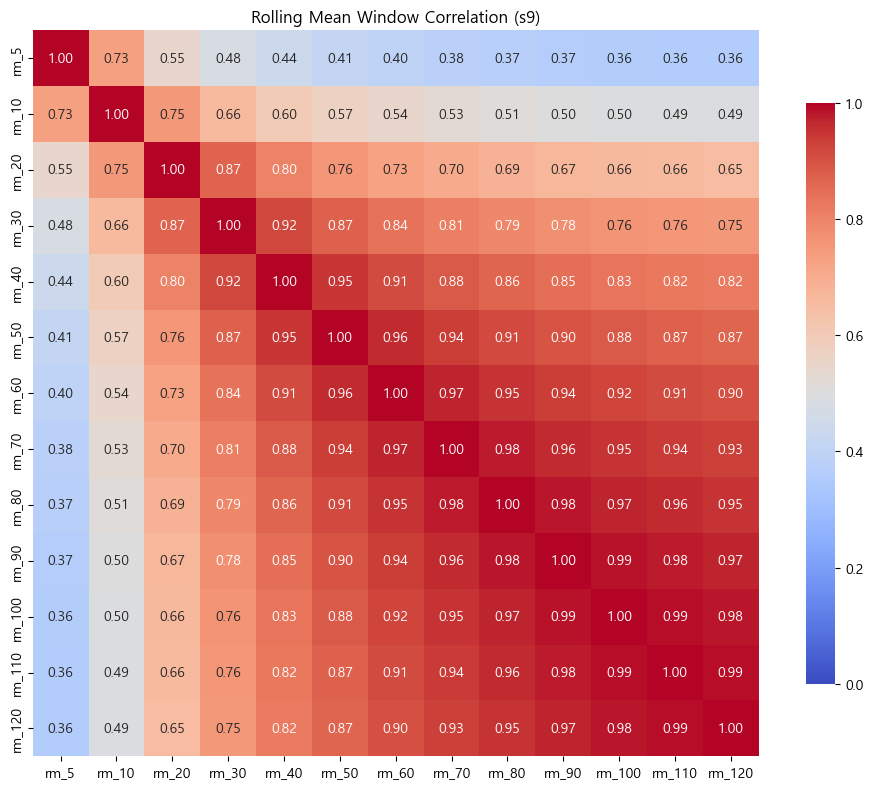

상관 0.95 이상 페어:
  rm_50 - rm_60: 0.962
  rm_60 - rm_70: 0.972
  rm_60 - rm_80: 0.952
  rm_70 - rm_80: 0.979
  rm_70 - rm_90: 0.963
  rm_70 - rm_100: 0.950
  rm_80 - rm_90: 0.984
  rm_80 - rm_100: 0.972
  rm_80 - rm_110: 0.961
  rm_80 - rm_120: 0.953
  rm_90 - rm_100: 0.987
  rm_90 - rm_110: 0.978
  rm_90 - rm_120: 0.969
  rm_100 - rm_110: 0.990
  rm_100 - rm_120: 0.982
  rm_110 - rm_120: 0.992


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 데이터 로드 (네 경로에 맞게 수정)
cols = ['unit', 'cycle'] + [f'op{i}' for i in range(1,4)] + [f's{i}' for i in range(1,22)]
df = pd.read_csv('../../CMAPSSData/train_FD004.txt', sep=r'\s+', header=None, names=cols)

# 2. 분석 대상 센서
target_sensor = 's9'  # 다른 센서로 바꿔서 반복 가능

# 3. 윈도우 리스트
windows = [5, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120]

# 4. Rolling Mean 피처 생성
feat_df = pd.DataFrame()
for w in windows:
    feat_df[f'rm_{w}'] = (
        df.groupby('unit')[target_sensor]
          .transform(lambda x: x.rolling(w, min_periods=1).mean())
    )

# 5. 상관행렬
corr = feat_df.corr()

# 6. 시각화
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', 
            vmin=0, vmax=1, square=True, cbar_kws={'shrink': 0.8})
plt.title(f'Rolling Mean Window Correlation ({target_sensor})')
plt.tight_layout()
plt.show()

# 7. 상관 0.95 이상인 페어 출력 (redundant 윈도우 찾기)
high_corr = []
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        if corr.iloc[i, j] > 0.95:
            high_corr.append((corr.columns[i], corr.columns[j], corr.iloc[i, j]))
print("상관 0.95 이상 페어:")
for pair in high_corr:
    print(f"  {pair[0]} - {pair[1]}: {pair[2]:.3f}")

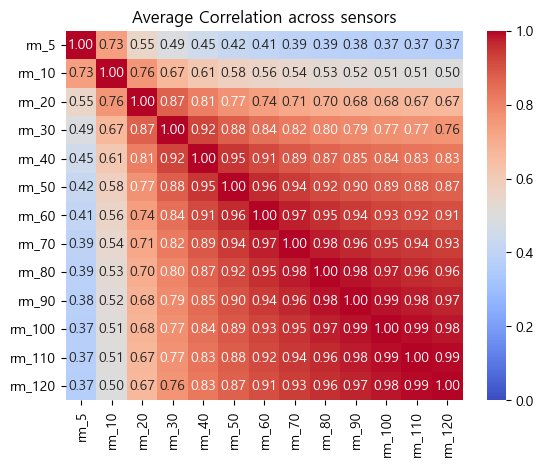

In [ ]:
# 센서별로 corr 평균내기
sensors_to_check = ['s2', 's7', 's11', 's12', 's14', 's21']
all_corrs = []
for s in sensors_to_check:
    feat_df = pd.DataFrame()
    for w in windows:
        feat_df[f'rm_{w}'] = df.groupby('unit')[s].transform(
            lambda x: x.rolling(w, min_periods=1).mean())
    all_corrs.append(feat_df.corr())

avg_corr = sum(all_corrs) / len(all_corrs)
sns.heatmap(avg_corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=0, vmax=1)
plt.title('Average Correlation across sensors')
plt.show()

## 6. 일반 실험 (기본 하이퍼파라미터)


 🏆 Ridge 최종 평가 결과 
 [Train] RMSE: 16.9527 | NASA Score: 1408854.95
 [Valid] RMSE: 19.7294 | NASA Score: 112776.54
 [Test] RMSE: 28.8549 | NASA Score: 6266.20


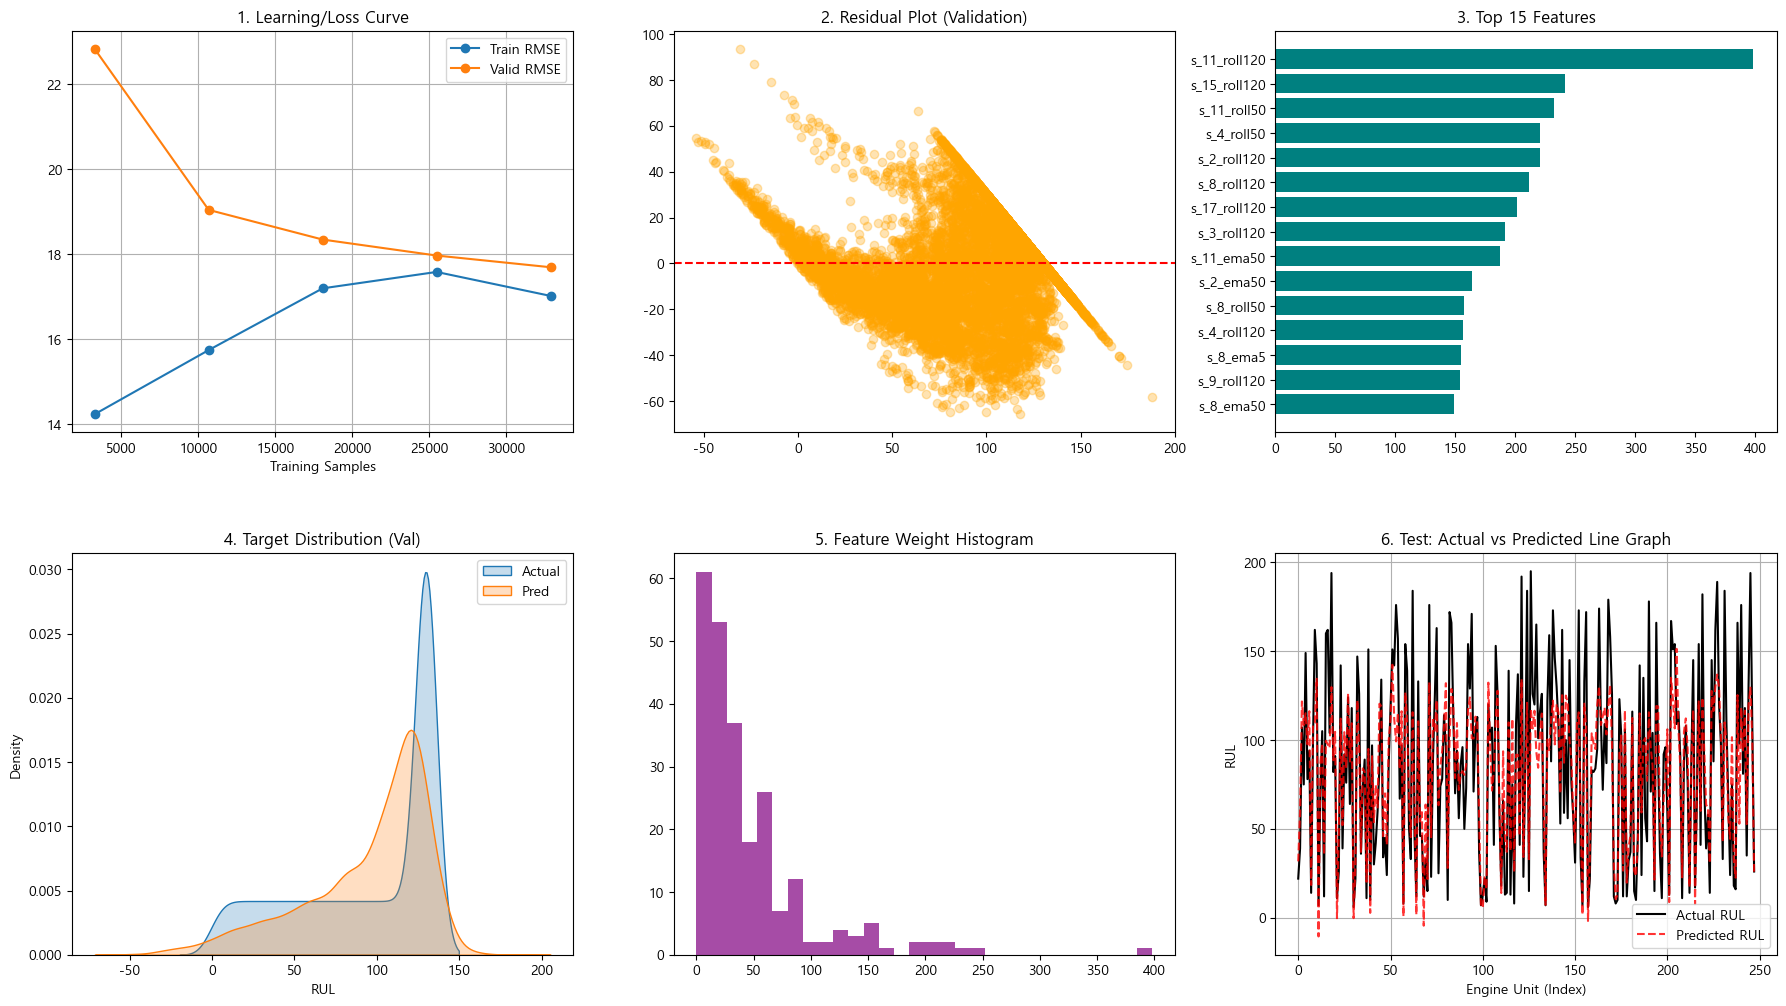

In [ ]:
# ── Ridge ─────────────────────────────────────────────────────────────────
ridge_params = {'alpha': 1.0, 'solver': 'auto', 'max_iter': 2000, 'random_state': RANDOM_STATE}
model_ridge  = Ridge(**ridge_params)
model_ridge.fit(X_train, y_train)
evaluate_full_pipeline(model_ridge, 'Ridge')



 🏆 Lasso 최종 평가 결과 
 [Train] RMSE: 23.9827 | NASA Score: 1056571.72
 [Valid] RMSE: 26.1340 | NASA Score: 266914.20
 [Test] RMSE: 35.9085 | NASA Score: 13608.66


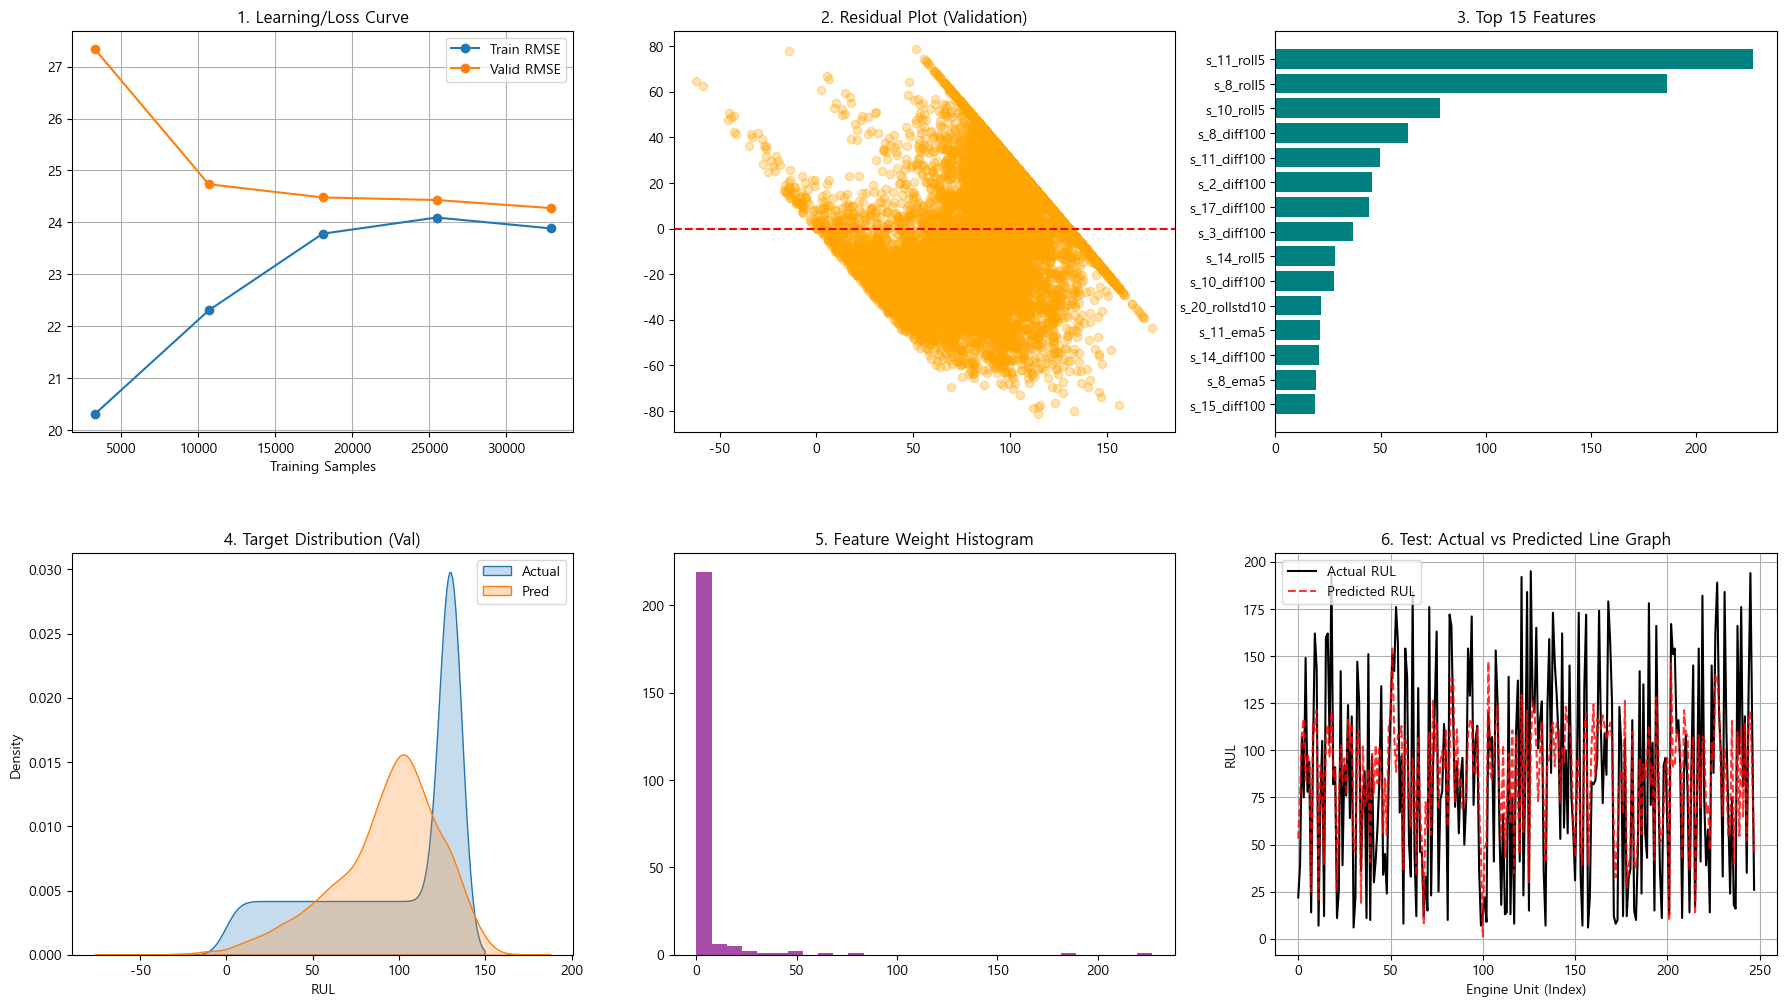

In [ ]:
# ── Lasso ─────────────────────────────────────────────────────────────────
lasso_params = {'alpha': 0.1, 'max_iter': 2000, 'random_state': RANDOM_STATE}
model_lasso  = Lasso(**lasso_params)
model_lasso.fit(X_train, y_train)
evaluate_full_pipeline(model_lasso, 'Lasso')



 🏆 ElasticNet 최종 평가 결과 
 [Train] RMSE: 29.4327 | NASA Score: 2922788.42
 [Valid] RMSE: 30.9945 | NASA Score: 872121.26
 [Test] RMSE: 43.4254 | NASA Score: 58879.41


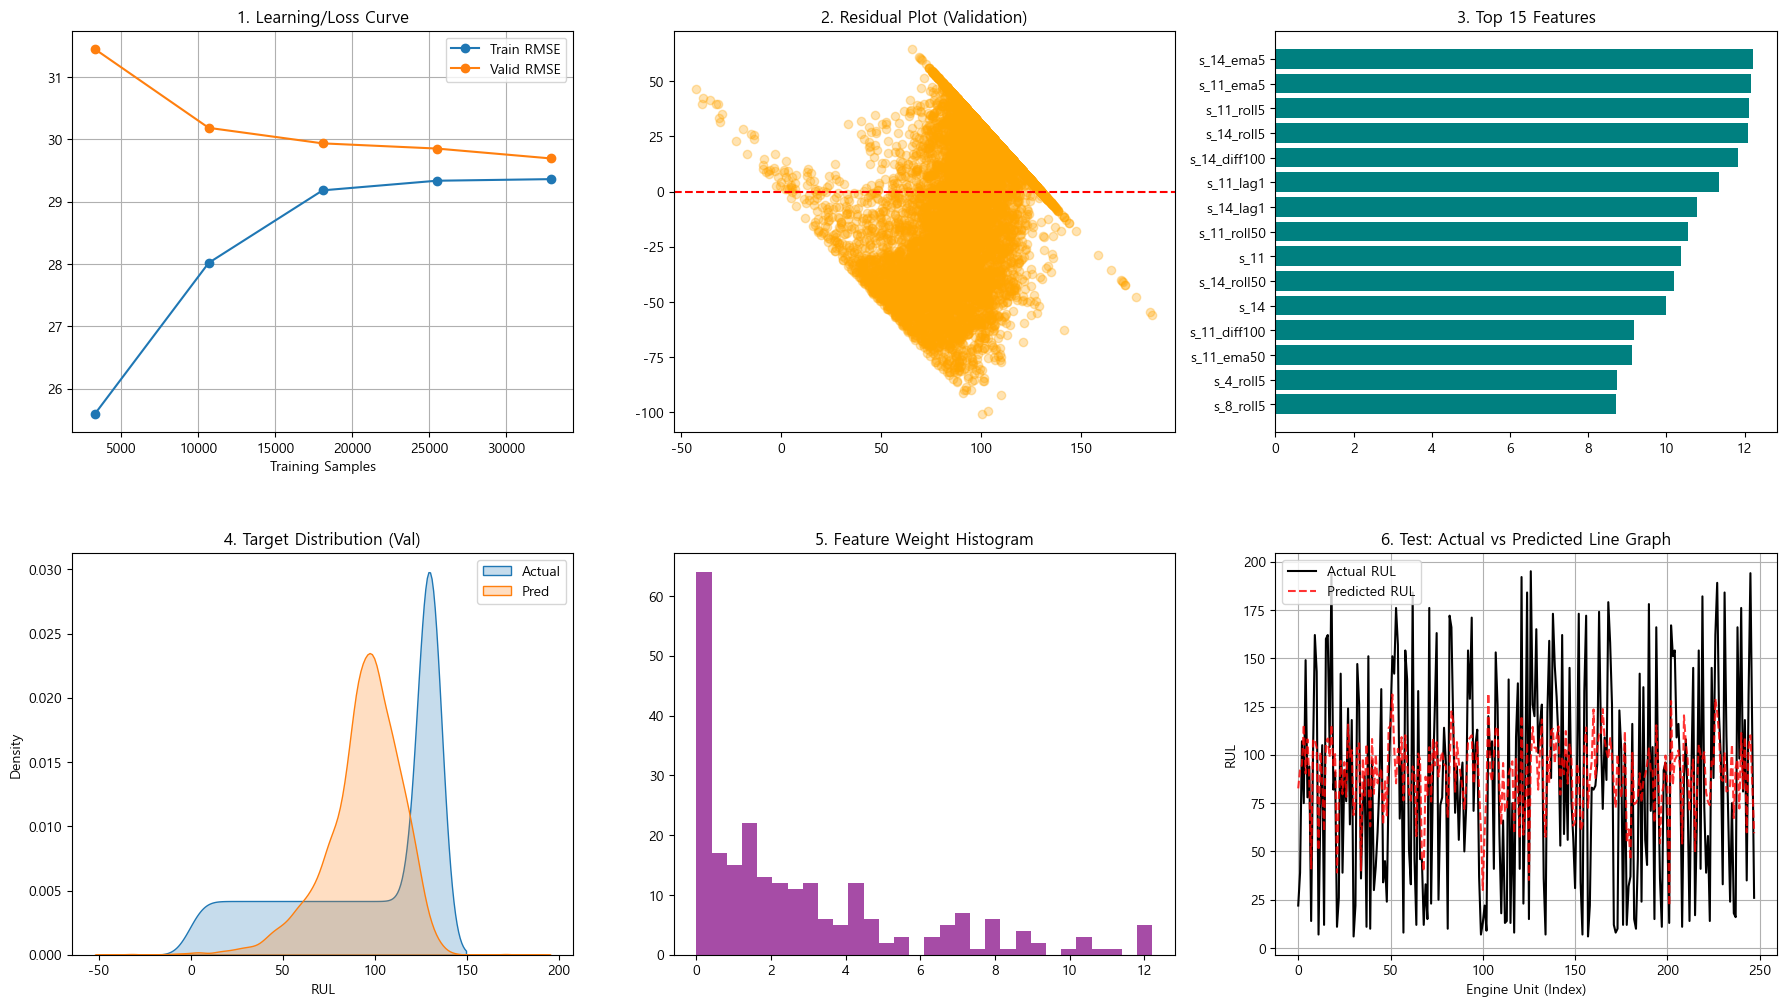

In [ ]:
# ── ElasticNet ────────────────────────────────────────────────────────────
elastic_params = {'alpha': 0.1, 'l1_ratio': 0.5, 'max_iter': 2000, 'random_state': RANDOM_STATE}
model_elastic  = ElasticNet(**elastic_params)
model_elastic.fit(X_train, y_train)
evaluate_full_pipeline(model_elastic, 'ElasticNet')



 🏆 RandomForest 최종 평가 결과 
 [Train] RMSE: 17.0608 | NASA Score: 295410.92
 [Valid] RMSE: 23.9983 | NASA Score: 264616.09
 [Test] RMSE: 33.4904 | NASA Score: 14330.23


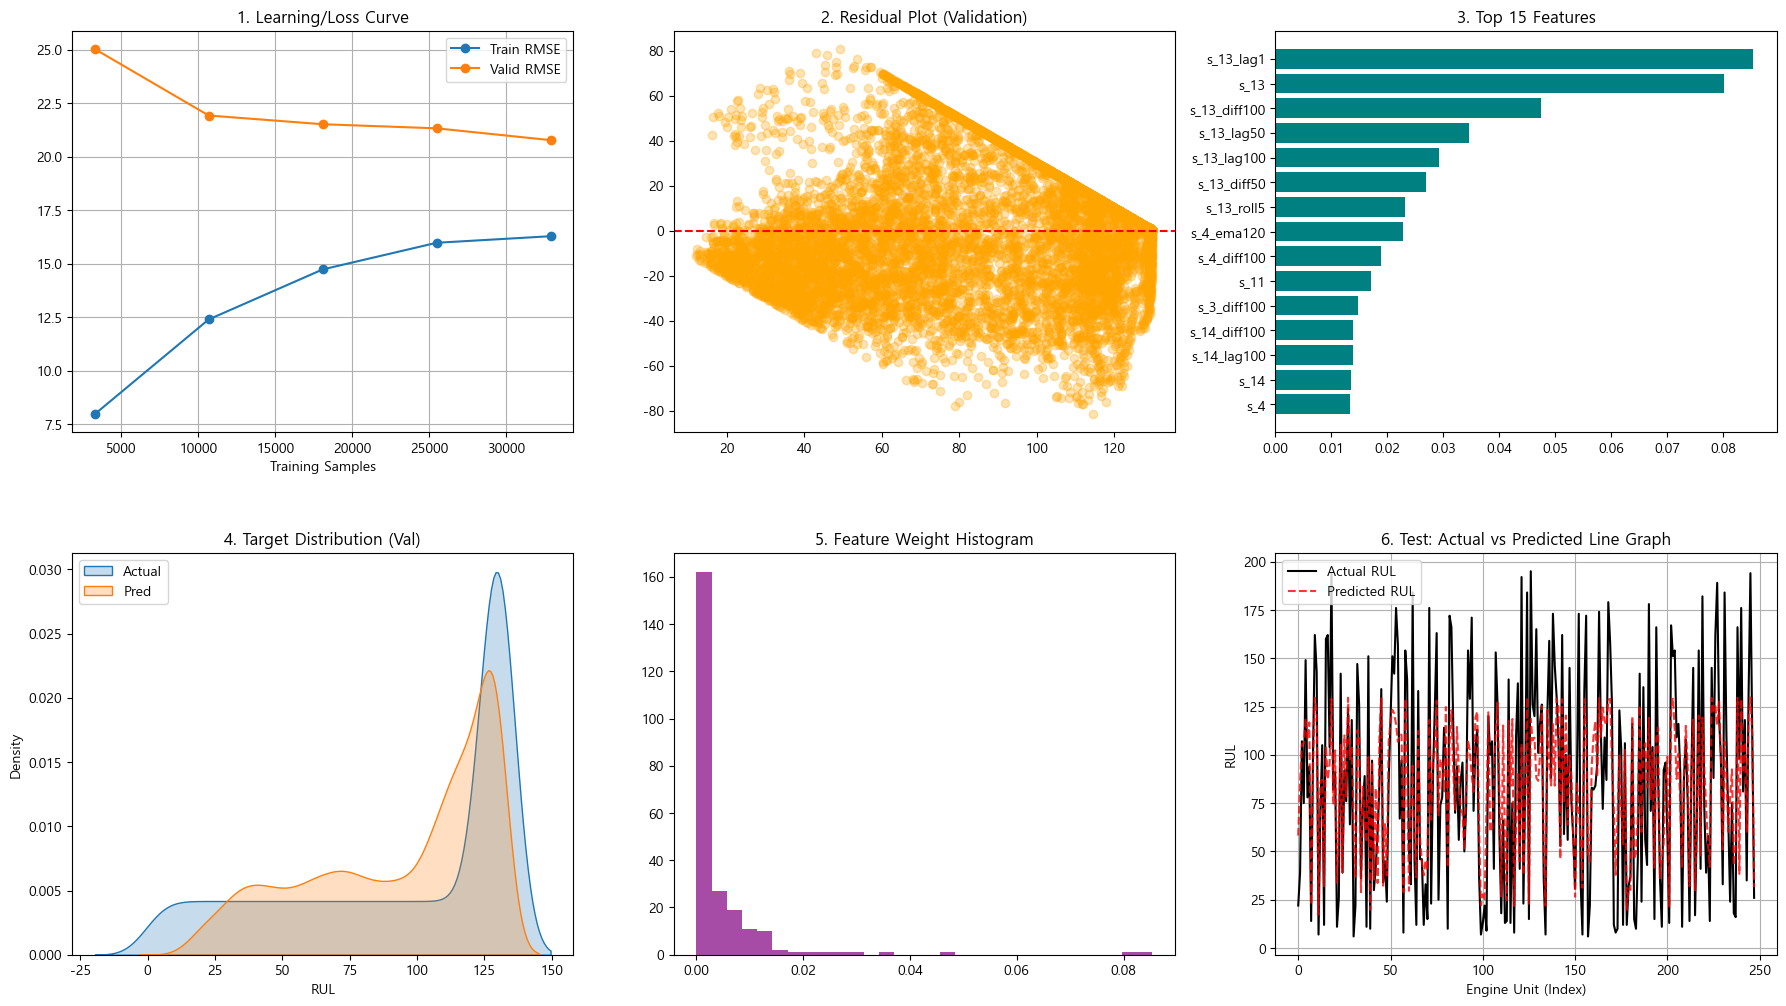

In [ ]:
# ── Random Forest ─────────────────────────────────────────────────────────
rf_params = {
    'n_estimators': 200, 'max_depth': 10,
    'min_samples_split': 5, 'min_samples_leaf': 2,
    'max_features': 'sqrt', 'n_jobs': -1, 'random_state': RANDOM_STATE
}
model_rf = RandomForestRegressor(**rf_params)
model_rf.fit(X_train, y_train)
evaluate_full_pipeline(model_rf, 'RandomForest', is_tree=True)



 🏆 LightGBM (gpu) 최종 평가 결과 
 [Train] RMSE: 10.4909 | NASA Score: 92160.11
 [Valid] RMSE: 20.6981 | NASA Score: 189898.53
 [Test] RMSE: 27.9399 | NASA Score: 6526.38


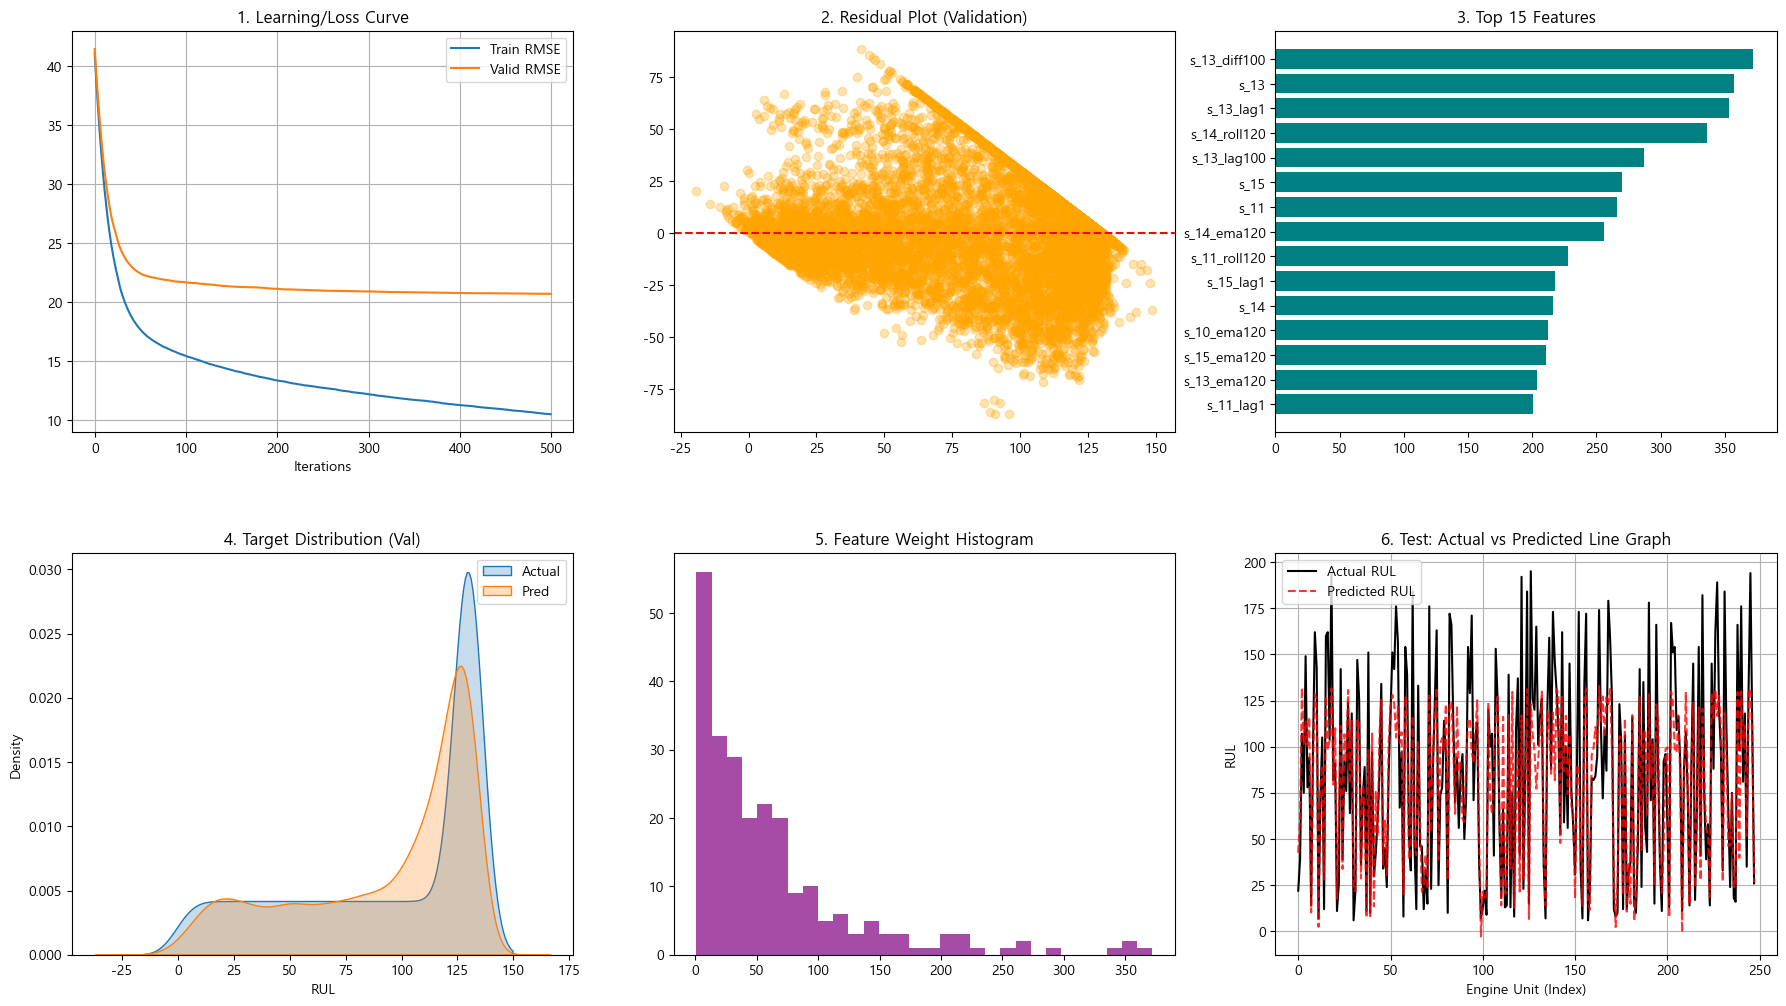

In [ ]:
# ── LightGBM ──────────────────────────────────────────────────────────────
lgb_params = {
    'n_estimators': 500, 'learning_rate': 0.05,
    'max_depth': 6, 'num_leaves': 31,
    'subsample': 0.8, 'colsample_bytree': 0.8,
    'reg_alpha': 0.1, 'reg_lambda': 1.0,
    'device': LGB_DEVICE,
    'random_state': RANDOM_STATE, 'n_jobs': -1, 'verbosity': -1
}
model_lgb = lgb.LGBMRegressor(**lgb_params)
model_lgb.fit(X_train, y_train,
              eval_set=[(X_train, y_train),(X_val, y_val)],
              eval_metric='rmse',
              callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(0)])
res_lgb  = model_lgb.evals_result_
eval_dict_lgb = {'train': res_lgb['training']['rmse'],
                 'valid': res_lgb['valid_1']['rmse']}
evaluate_full_pipeline(model_lgb, f'LightGBM ({LGB_DEVICE})', is_tree=True, is_boosting=True, eval_results=eval_dict_lgb)



 🏆 XGBoost (cuda) 최종 평가 결과 
 [Train] RMSE: 8.7643 | NASA Score: 60252.50
 [Valid] RMSE: 20.5360 | NASA Score: 350958.65
 [Test] RMSE: 27.4522 | NASA Score: 5916.92


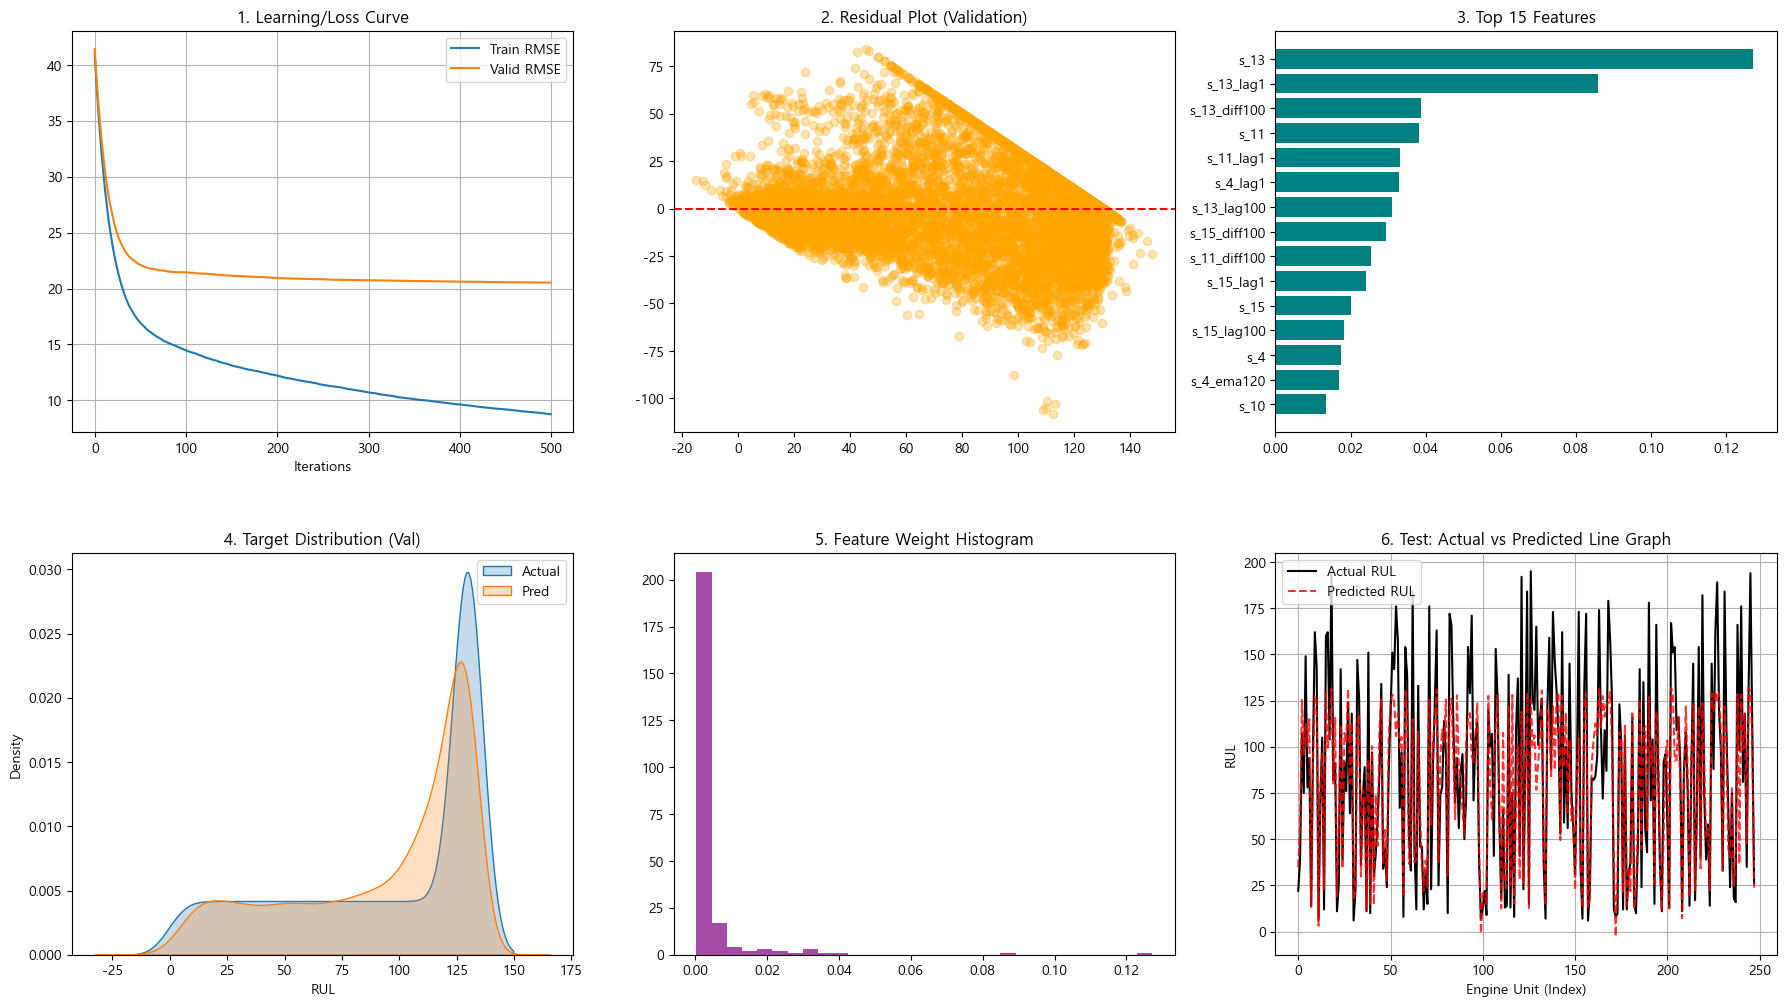

In [ ]:
# ── XGBoost ───────────────────────────────────────────────────────────────
xgb_params = {
    'n_estimators': 500, 'learning_rate': 0.05, 'max_depth': 6,
    'subsample': 0.8, 'colsample_bytree': 0.8,
    'reg_alpha': 0.1, 'reg_lambda': 1.0,
    'tree_method': 'hist', 'device': XGB_DEVICE,
    'random_state': RANDOM_STATE, 'n_jobs': -1, 'verbosity': 0
}
model_xgb = xgb.XGBRegressor(**xgb_params)
model_xgb.fit(X_train, y_train,
              eval_set=[(X_train, y_train),(X_val, y_val)], verbose=False)
res_xgb = model_xgb.evals_result()
eval_dict_xgb = {'train': res_xgb['validation_0']['rmse'],
                 'valid': res_xgb['validation_1']['rmse']}
evaluate_full_pipeline(model_xgb, f'XGBoost ({XGB_DEVICE})', is_tree=True, is_boosting=True, eval_results=eval_dict_xgb)


# 모델 저장 pkl

In [ ]:
import pickle 
import os

# 1. 저장 폴더 생성
save_dir = 'saved_models'
os.makedirs(save_dir, exist_ok=True)

# 2. 전처리 에셋 저장 (필수)
preprocess_assets = {
    'op_scaler': data.get('op_scaler'),
    'kmeans': data.get('kmeans'),
    'scalers': data.get('scalers'),
    'useful_sensors': data.get('useful_sensors'),
    'ml_features': data.get('ml_features'),
    'ohe_cols': data.get('ohe_cols'),
    'config': CONFIG
}

# 파일 확장자를 .pkl로 변경
preprocess_filename = f"{save_dir}/preprocess_{CONFIG['subset']}.pkl"

# pickle.dump를 사용하여 저장 (wb: 쓰기/바이너리 모드 필수)
with open(preprocess_filename, 'wb') as f:
    pickle.dump(preprocess_assets, f)
print(f"✅ [전처리] {CONFIG['subset']} 에셋 저장 완료 (.pkl)")

# 3. 모델 통합 저장 루프
models_to_save = [
    ('model_xgb', 'XGBoost'),
    ('model_lgb', 'LightGBM'),
    ('model_rf',  'RF'),
    ('model_ridge','Ridge'),
    ('model_lasso','Lasso'),
    ('model_enet', 'ElasticNet')
]

print("-" * 30)
for var_name, model_label in models_to_save:
    if var_name in globals() and globals()[var_name] is not None:
        model_obj = globals()[var_name]
        # 파일 확장자 .pkl로 변경
        save_path = f"{save_dir}/model_{model_label}_{CONFIG['subset']}.pkl"
        
        # 바이너리 모드로 파일 열기 후 저장
        with open(save_path, 'wb') as f:
            pickle.dump(model_obj, f)
        print(f"✅ [모델] {model_label} 저장 성공: {save_path}")
    else:
        pass
print("-" * 30)
print("🚀 모든 가용 자산 저장 프로세스 종료")

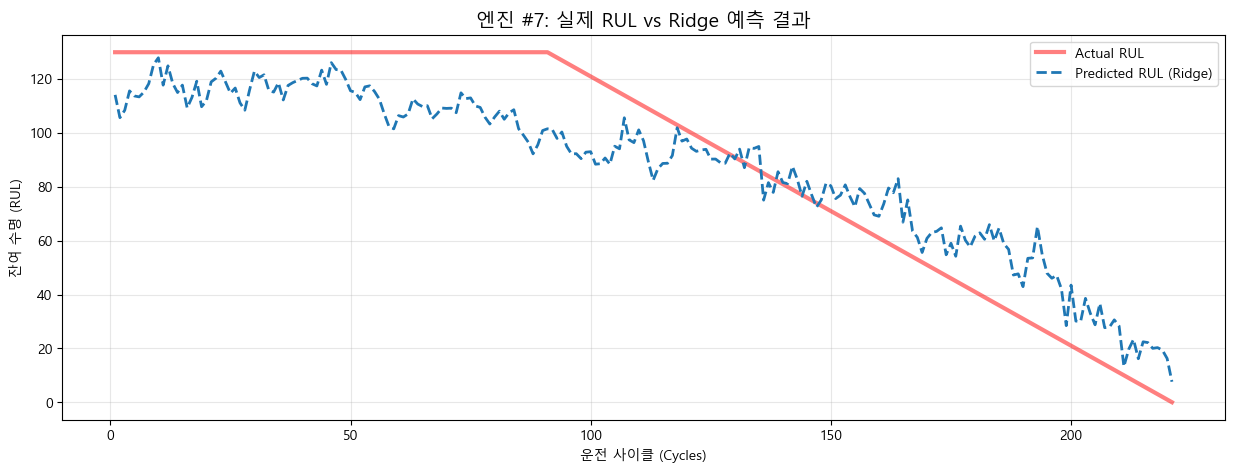

----------------------------------------------------------------------------------------------------


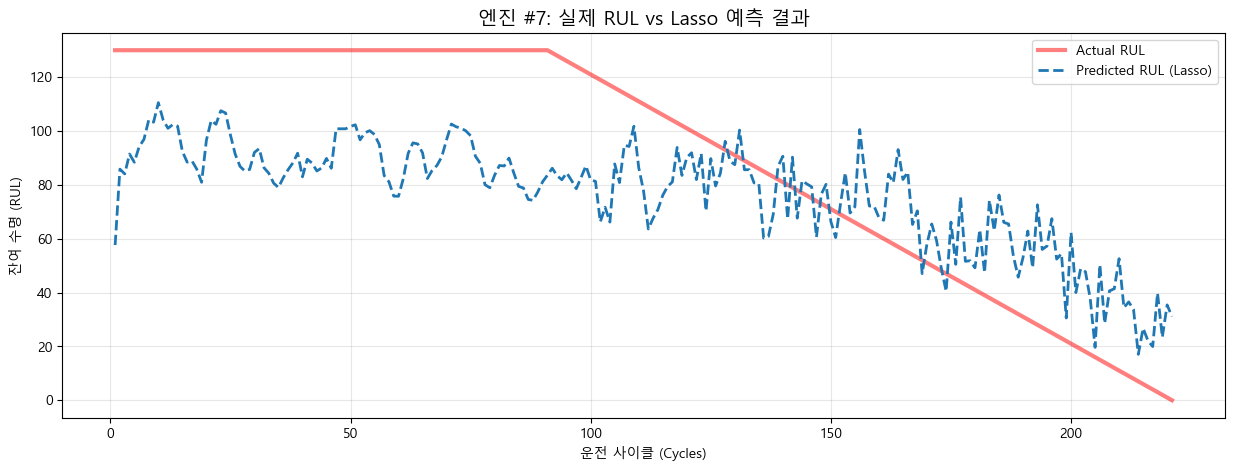

----------------------------------------------------------------------------------------------------


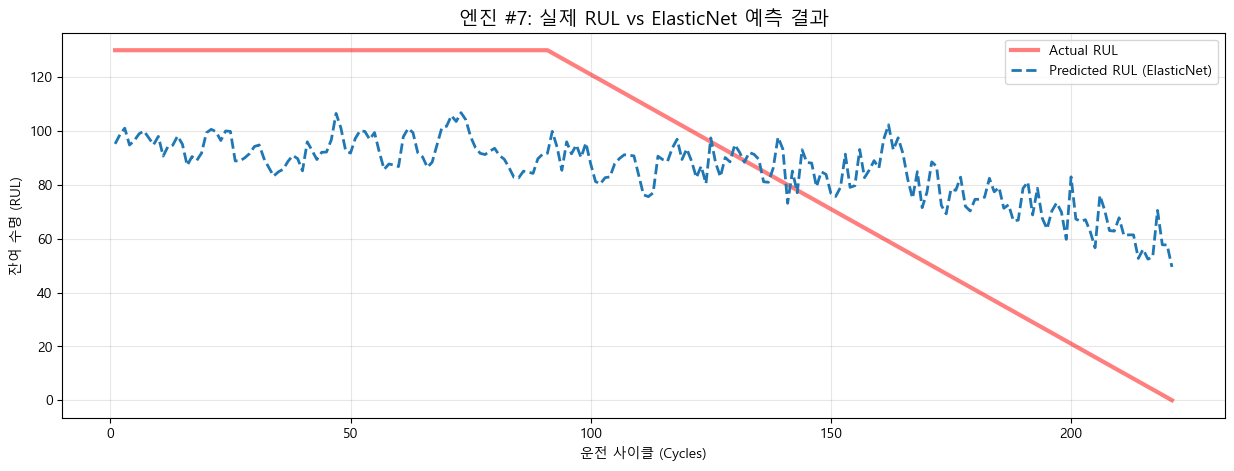

----------------------------------------------------------------------------------------------------


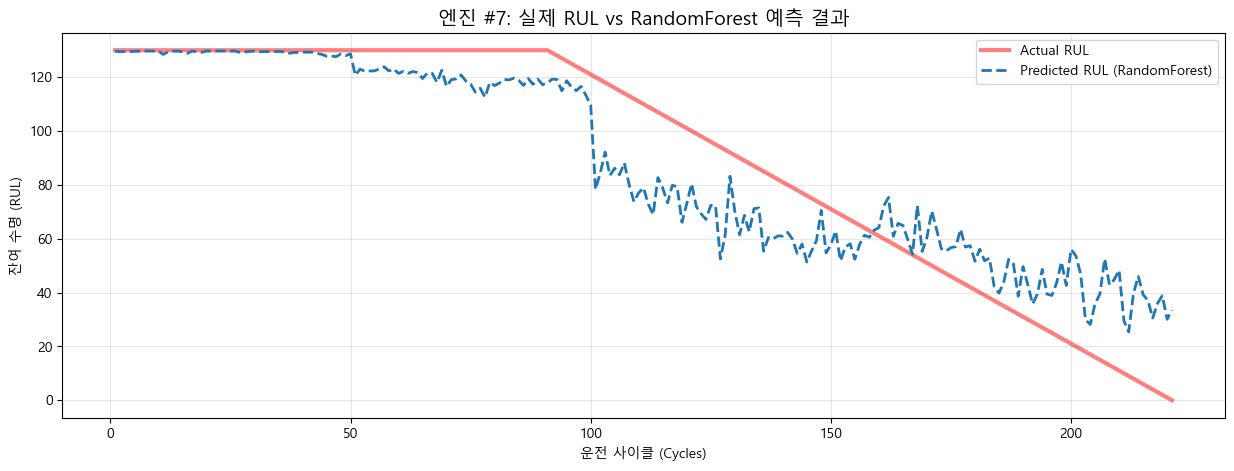

----------------------------------------------------------------------------------------------------


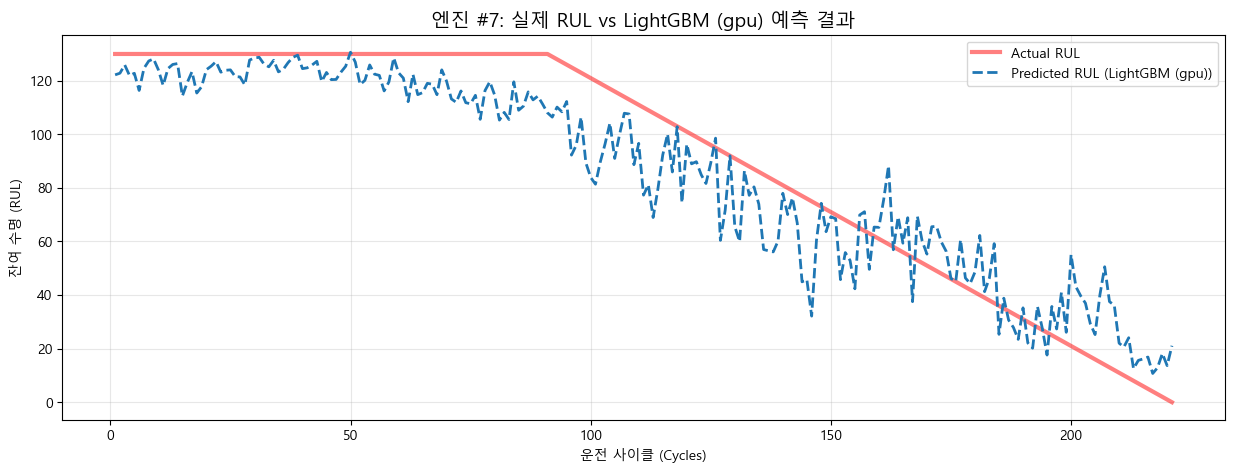

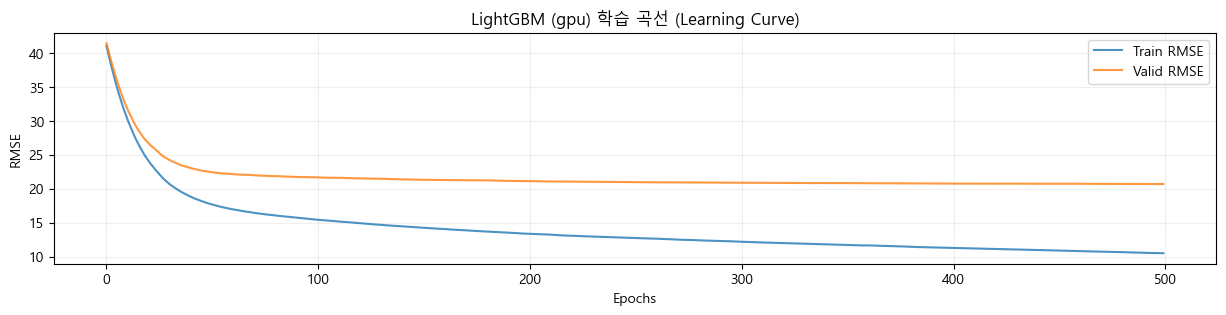

----------------------------------------------------------------------------------------------------


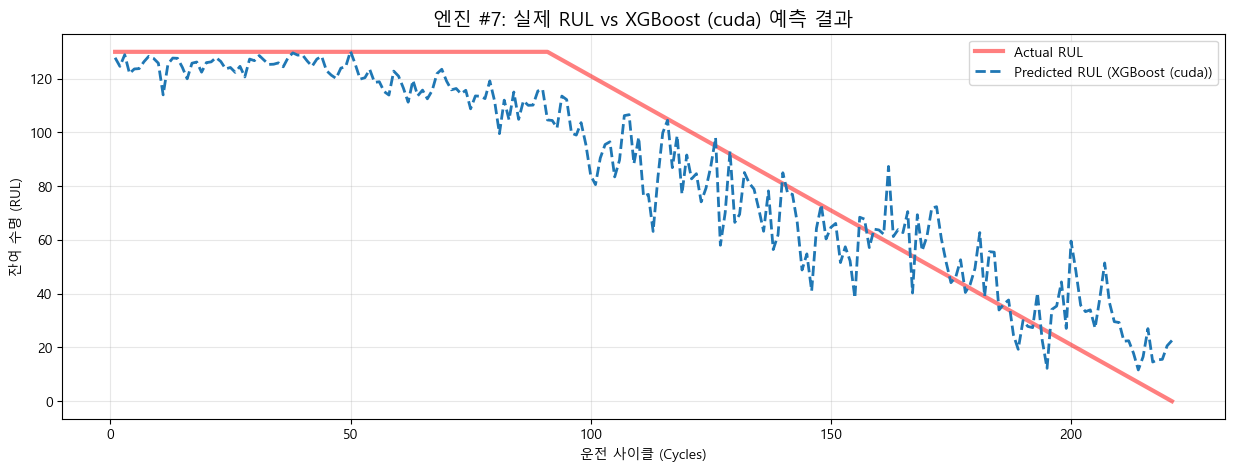

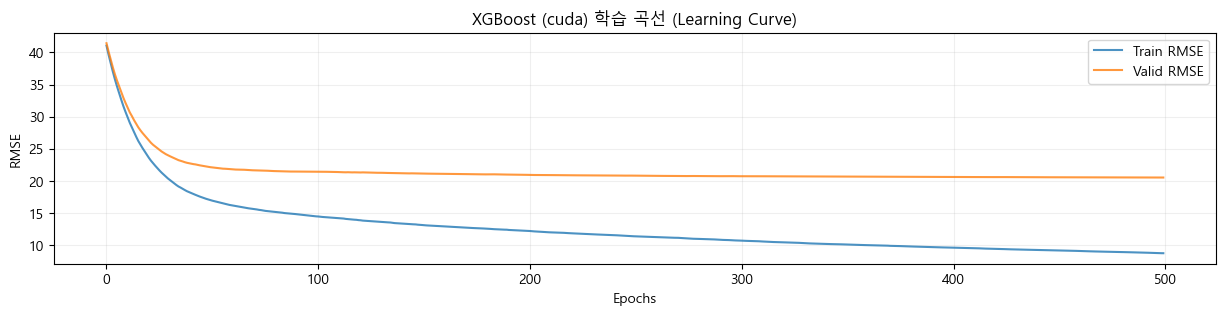

----------------------------------------------------------------------------------------------------


In [16]:
import matplotlib.pyplot as plt

# 시각화할 모델 리스트 구성 (모델 객체, 모델 이름, 학습 곡선 데이터)
models_to_plot = [
    (model_ridge, 'Ridge', None),
    (model_lasso, 'Lasso', None),
    (model_elastic, 'ElasticNet', None),
    (model_rf, 'RandomForest', None),
    (model_lgb, f'LightGBM ({LGB_DEVICE})', eval_dict_lgb),
    (model_xgb, f'XGBoost ({XGB_DEVICE})', eval_dict_xgb)
]

# 검증 세트에서 시각화할 첫 번째 엔진 샘플 추출
sample_val_unit = valid_ml['unit_nr'].unique()[0]
sample_mask = valid_ml['unit_nr'] == sample_val_unit
time_cycles = valid_ml[sample_mask]['time_cycles']
actual_rul = y_val[sample_mask]

for model, name, eval_dict in models_to_plot:
    # --- 1. RUL 예측 결과 시각화 ---
    plt.figure(figsize=(15, 5))
    
    # 해당 모델로 전체 검증셋 예측 후 샘플 엔진 구간만 추출
    y_pred_all = model.predict(X_val)
    y_pred_sample = y_pred_all[sample_mask]
    
    plt.plot(time_cycles, actual_rul, label='Actual RUL', color='red', lw=3, alpha=0.5)
    plt.plot(time_cycles, y_pred_sample, label=f'Predicted RUL ({name})', linestyle='--', lw=2)
    
    plt.title(f'엔진 #{sample_val_unit}: 실제 RUL vs {name} 예측 결과', fontsize=14)
    plt.xlabel('운전 사이클 (Cycles)')
    plt.ylabel('잔여 수명 (RUL)')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    # --- 2. 학습 곡선 시각화 (LGBM, XGBoost 등 eval_results가 있는 경우만) ---
    if eval_dict is not None:
        plt.figure(figsize=(15, 3))
        plt.plot(eval_dict['train'], label='Train RMSE', alpha=0.8)
        plt.plot(eval_dict['valid'], label='Valid RMSE', alpha=0.8)
        plt.title(f'{name} 학습 곡선 (Learning Curve)', fontsize=12)
        plt.xlabel('Epochs')
        plt.ylabel('RMSE')
        plt.legend()
        plt.grid(True, alpha=0.2)
        plt.show()
    
    print("-" * 100)

## 7. Optuna 튜닝 설정

In [ ]:
# ============================================================
# ⚙️ OPTUNA 설정
# ============================================================
N_TRIALS_LIN    = 30      # 선형 모델
N_TRIALS_TREE   = 50      # 트리 모델
OPTUNA_METRIC   = 'rmse'  # 'rmse' | 'nasa'
N_SPLITS        = 5       # GroupKFold
INNER_VAL_RATIO = 0.15    # ES용 inner-val 비율

groups = train_ml['unit_nr'].values
gkf    = GroupKFold(n_splits=N_SPLITS)

ALL_RESULTS = {}
BEST_MODELS = {}

# ── 헬퍼 ──────────────────────────────────────────────────────────────────
def clip_rul(pred, cap=CONFIG['rul_cap']):
    return np.clip(pred, 0, cap)

def cv_score(builder, X, y, grp, metric=OPTUNA_METRIC):
    rmse_list, nasa_list = [], []
    for ti, vi in gkf.split(X, y, grp):
        m = builder()
        m.fit(X.iloc[ti], y.iloc[ti])
        pred = clip_rul(m.predict(X.iloc[vi]))
        rmse_list.append(float(np.sqrt(mean_squared_error(y.iloc[vi], pred))))
        nasa_list.append(float(calculate_nasa_score(y.iloc[vi], pred) / max(len(y.iloc[vi]), 1)))
    return {'cv_rmse_mean': float(np.mean(rmse_list)), 'cv_nasa_mean': float(np.mean(nasa_list))}

def _inner_split(X, y, grp, val_ratio=INNER_VAL_RATIO, seed=RANDOM_STATE):
    rng   = np.random.default_rng(seed)
    units = np.array(sorted(set(grp)))
    rng.shuffle(units)
    n_va  = max(1, int(len(units) * val_ratio))
    va_set = set(units[:n_va])
    mask   = np.array([g in va_set for g in grp])
    return X[~mask], y[~mask], X[mask], y[mask]

def _fit_with_es(model, name, Xtr, ytr, Xva=None, yva=None):
    if name == 'RandomForest' or Xva is None:
        model.fit(Xtr, ytr)
    elif name == 'XGBoost':
        model.fit(Xtr, ytr, eval_set=[(Xva, yva)], verbose=False)
    elif name == 'LightGBM':
        model.fit(Xtr, ytr, eval_set=[(Xva, yva)],
                  callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(0)])

def cv_score_es(builder, X, y, grp, name, metric=OPTUNA_METRIC):
    rmse_list, nasa_list = [], []
    for ti, vi in gkf.split(X, y, grp):
        Xtr_f = X.iloc[ti]; ytr_f = y.iloc[ti]
        Xva   = X.iloc[vi]; yva   = y.iloc[vi]
        model = builder()
        if name in ('XGBoost', 'LightGBM'):
            X_in, y_in, X_iv, y_iv = _inner_split(
                Xtr_f.values, ytr_f.values, grp[ti])
            X_in = pd.DataFrame(X_in, columns=X.columns)
            X_iv = pd.DataFrame(X_iv, columns=X.columns)
            _fit_with_es(model, name, X_in, pd.Series(y_in), X_iv, pd.Series(y_iv))
        else:
            _fit_with_es(model, name, Xtr_f, ytr_f)
        pred = clip_rul(model.predict(Xva))
        rmse_list.append(float(np.sqrt(mean_squared_error(yva, pred))))
        nasa_list.append(float(calculate_nasa_score(yva, pred) / max(len(yva), 1)))
    return {'cv_rmse_mean': float(np.mean(rmse_list)),
            'cv_rmse_std' : float(np.std(rmse_list)),
            'cv_nasa_mean': float(np.mean(nasa_list))}

print('✅ Optuna 설정 완료')
print(f'   N_TRIALS: 선형={N_TRIALS_LIN} / 트리={N_TRIALS_TREE}')
print(f'   Metric  : {OPTUNA_METRIC.upper()} | CV splits: {N_SPLITS}')


## 8. Optuna — 선형 모델 (Ridge / Lasso / ElasticNet)

In [ ]:
def _build_linear(trial, name):
    if name == 'Ridge':
        return Ridge(alpha=trial.suggest_float('alpha', 0.01, 500, log=True),
                     solver=trial.suggest_categorical('solver', ['auto','svd','cholesky','lsqr']),
                     max_iter=3000, random_state=RANDOM_STATE)
    elif name == 'Lasso':
        return Lasso(alpha=trial.suggest_float('alpha', 1e-4, 10, log=True),
                     selection=trial.suggest_categorical('selection', ['cyclic','random']),
                     max_iter=3000, tol=0.001, random_state=RANDOM_STATE)
    elif name == 'ElasticNet':
        return ElasticNet(alpha=trial.suggest_float('alpha', 1e-4, 10, log=True),
                          l1_ratio=trial.suggest_float('l1_ratio', 0.05, 0.95),
                          selection=trial.suggest_categorical('selection', ['cyclic','random']),
                          max_iter=3000, tol=0.001, random_state=RANDOM_STATE)
    raise ValueError(name)

for mname in ['Ridge', 'Lasso', 'ElasticNet']:
    t0 = time.time()
    print(f'[{mname}] 최적화 시작 ... ({N_TRIALS_LIN} trials)', end='', flush=True)

    def _obj_lin(trial, _m=mname):
        res = cv_score(lambda: _build_linear(trial, _m), X_train, y_train, groups)
        return res['cv_nasa_mean'] if OPTUNA_METRIC == 'nasa' else res['cv_rmse_mean']

    study = optuna.create_study(direction='minimize', sampler=TPESampler(seed=RANDOM_STATE))
    study.optimize(_obj_lin, n_trials=N_TRIALS_LIN, show_progress_bar=False)

    best_p = study.best_params
    best_m = _build_linear(optuna.trial.FixedTrial(best_p), mname)
    best_m.fit(X_train, y_train)

    cv_res    = cv_score(lambda: _build_linear(optuna.trial.FixedTrial(best_p), mname),
                         X_train, y_train, groups)
    val_mets  = get_metrics(y_val,  best_m.predict(X_val))
    test_mets = get_metrics(y_test, best_m.predict(X_test))

    ALL_RESULTS[mname] = {
        'type':'linear', 'model':best_m, 'params':best_p,
        'cv_rmse':cv_res['cv_rmse_mean'], 'cv_nasa':cv_res['cv_nasa_mean'],
        'val_metrics':val_mets, 'test_metrics':test_mets, 'fit_seconds':time.time()-t0
    }
    BEST_MODELS[mname] = best_m

    print(f'  ✅ | CV RMSE={cv_res["cv_rmse_mean"]:.3f} '
          f'| Val RMSE={val_mets["RMSE"]:.3f} '
          f'| Test NASA={test_mets["NASA_Score"]:.1f} '
          f'| {time.time()-t0:.0f}s')
    print(f'   best_params: {best_p}')

print('\n✅ 선형 모델 최적화 완료')


## 9. Optuna — RandomForest (CPU)

In [ ]:
def _build_rf(trial):
    return RandomForestRegressor(
        n_estimators      = trial.suggest_int  ('n_estimators',    100, 600),
        max_depth         = trial.suggest_int  ('max_depth',         5,  30),
        min_samples_split = trial.suggest_int  ('min_samples_split', 2,  20),
        min_samples_leaf  = trial.suggest_int  ('min_samples_leaf',  1,  10),
        max_features      = trial.suggest_float('max_features',     0.2, 1.0),
        random_state=RANDOM_STATE, n_jobs=-1)

t0 = time.time()
print(f'[RandomForest] 최적화 시작 ... ({N_TRIALS_TREE} trials)')

study_rf = optuna.create_study(direction='minimize', sampler=TPESampler(seed=RANDOM_STATE))
study_rf.optimize(
    lambda t: cv_score_es(lambda: _build_rf(t), X_train, y_train, groups, 'RandomForest')
             ['cv_nasa_mean' if OPTUNA_METRIC=='nasa' else 'cv_rmse_mean'],
    n_trials=N_TRIALS_TREE, show_progress_bar=False)

best_p = study_rf.best_params
best_m = _build_rf(optuna.trial.FixedTrial(best_p))
best_m.fit(X_train, y_train)

cv_res    = cv_score_es(lambda: _build_rf(optuna.trial.FixedTrial(best_p)),
                         X_train, y_train, groups, 'RandomForest')
val_mets  = get_metrics(y_val,  best_m.predict(X_val))
test_mets = get_metrics(y_test, best_m.predict(X_test))

ALL_RESULTS['RandomForest'] = {
    'type':'tree', 'model':best_m, 'params':best_p,
    'cv_rmse':cv_res['cv_rmse_mean'], 'cv_rmse_std':cv_res['cv_rmse_std'],
    'cv_nasa':cv_res['cv_nasa_mean'],
    'val_metrics':val_mets, 'test_metrics':test_mets, 'fit_seconds':time.time()-t0
}
BEST_MODELS['RandomForest'] = best_m

print(f'  ✅ | CV RMSE={cv_res["cv_rmse_mean"]:.3f} | Val RMSE={val_mets["RMSE"]:.3f} '
      f'| Test NASA={test_mets["NASA_Score"]:.1f} | {time.time()-t0:.0f}s')
print(f'   best_params: {best_p}')


## 10. Optuna — XGBoost / LightGBM (GPU 자동)

In [ ]:
def _build_boost(trial, name):
    if name == 'XGBoost':
        return xgb.XGBRegressor(
            n_estimators          = trial.suggest_int  ('n_estimators',     150, 700),
            max_depth             = trial.suggest_int  ('max_depth',          3,  10),
            learning_rate         = trial.suggest_float('learning_rate',   0.01, 0.3,  log=True),
            subsample             = trial.suggest_float('subsample',        0.5, 1.0),
            colsample_bytree      = trial.suggest_float('colsample_bytree', 0.5, 1.0),
            reg_alpha             = trial.suggest_float('reg_alpha',       1e-8,  10,  log=True),
            reg_lambda            = trial.suggest_float('reg_lambda',      1e-8,  10,  log=True),
            early_stopping_rounds = 30,
            tree_method='hist', device=XGB_DEVICE,
            random_state=RANDOM_STATE, n_jobs=-1, verbosity=0)
    elif name == 'LightGBM':
        return lgb.LGBMRegressor(
            n_estimators     = trial.suggest_int  ('n_estimators',    150, 700),
            max_depth        = trial.suggest_int  ('max_depth',         3,  12),
            learning_rate    = trial.suggest_float('learning_rate',  0.01, 0.3,  log=True),
            num_leaves       = trial.suggest_int  ('num_leaves',       15, 255),
            subsample        = trial.suggest_float('subsample',       0.5, 1.0),
            colsample_bytree = trial.suggest_float('colsample_bytree',0.5, 1.0),
            reg_alpha        = trial.suggest_float('reg_alpha',      1e-8,  10,  log=True),
            reg_lambda       = trial.suggest_float('reg_lambda',     1e-8,  10,  log=True),
            device=LGB_DEVICE, random_state=RANDOM_STATE, n_jobs=-1, verbosity=-1)
    raise ValueError(name)

for mname in ['XGBoost', 'LightGBM']:
    t0  = time.time()
    dev = XGB_DEVICE if mname == 'XGBoost' else LGB_DEVICE
    print(f'[{mname}] 최적화 시작 ... ({N_TRIALS_TREE} trials) | device={dev}')

    study = optuna.create_study(direction='minimize', sampler=TPESampler(seed=RANDOM_STATE))
    study.optimize(
        lambda t, _m=mname: cv_score_es(lambda: _build_boost(t, _m), X_train, y_train, groups, _m)
                            ['cv_nasa_mean' if OPTUNA_METRIC=='nasa' else 'cv_rmse_mean'],
        n_trials=N_TRIALS_TREE, show_progress_bar=False)

    best_p = study.best_params
    best_m = _build_boost(optuna.trial.FixedTrial(best_p), mname)

    X_in, y_in, X_iv, y_iv = _inner_split(X_train.values, y_train.values, groups)
    X_in = pd.DataFrame(X_in, columns=ML_FEATURES)
    X_iv = pd.DataFrame(X_iv, columns=ML_FEATURES)
    _fit_with_es(best_m, mname, X_in, pd.Series(y_in), X_iv, pd.Series(y_iv))

    cv_res    = cv_score_es(lambda: _build_boost(optuna.trial.FixedTrial(best_p), mname),
                             X_train, y_train, groups, mname)
    val_mets  = get_metrics(y_val,  best_m.predict(X_val))
    test_mets = get_metrics(y_test, best_m.predict(X_test))

    ALL_RESULTS[mname] = {
        'type':'tree', 'model':best_m, 'params':best_p,
        'cv_rmse':cv_res['cv_rmse_mean'], 'cv_rmse_std':cv_res['cv_rmse_std'],
        'cv_nasa':cv_res['cv_nasa_mean'],
        'val_metrics':val_mets, 'test_metrics':test_mets, 'fit_seconds':time.time()-t0
    }
    BEST_MODELS[mname] = best_m

    print(f'  ✅ | CV RMSE={cv_res["cv_rmse_mean"]:.3f}±{cv_res["cv_rmse_std"]:.3f} '
          f'| Val RMSE={val_mets["RMSE"]:.3f} '
          f'| Test NASA={test_mets["NASA_Score"]:.1f} '
          f'| {time.time()-t0:.0f}s')
    print(f'   best_params: {best_p}')

print('\n✅ Boosting 모델 최적화 완료')


## 11. 전체 모델 비교표

In [17]:
rows = []
for mname, res in ALL_RESULTS.items():
    rows.append({
        'Model'    : mname,
        'CV_RMSE'  : round(res['cv_rmse'], 4),
        'Val_RMSE' : round(res['val_metrics']['RMSE'], 4),
        'Val_NASA' : round(res['val_metrics']['NASA_Score'], 1),
        'Test_RMSE': round(res['test_metrics']['RMSE'], 4),
        'Test_NASA': round(res['test_metrics']['NASA_Score'], 1),
        'Test_R2'  : round(res['test_metrics']['R2'], 4),
        'Time(s)'  : round(res['fit_seconds'], 1),
    })

summary_df = pd.DataFrame(rows).sort_values('Test_RMSE').reset_index(drop=True)
print('\n' + '='*70)
print('📊 모델 성능 비교표 — FD003 (Test RMSE 기준 정렬)')
print('='*70)
print(summary_df.to_string(index=False))
print('='*70)

best_name = summary_df.iloc[0]['Model']
print(f'\n🏆 최고 성능 모델: {best_name}')
print(f'   Test RMSE  = {summary_df.iloc[0]["Test_RMSE"]}')
print(f'   Test NASA  = {summary_df.iloc[0]["Test_NASA"]}')
print(f'   Test R²    = {summary_df.iloc[0]["Test_R2"]}')


NameError: name 'ALL_RESULTS' is not defined

## 12. Optuna 최적 파라미터로 재시각화 (원하는 모델 선택)

In [ ]:
# ── 재평가할 모델 이름 지정 ────────────────────────────────────────────────
TARGET_MODEL = best_name   # 또는 'XGBoost', 'LightGBM', 'Ridge' 등 직접 지정

best_model = BEST_MODELS[TARGET_MODEL]
res_info   = ALL_RESULTS[TARGET_MODEL]
is_tree    = res_info['type'] == 'tree'
is_boost   = TARGET_MODEL in ('XGBoost', 'LightGBM')

print(f'🎯 [{TARGET_MODEL}] 최적 파라미터 시각화')
print(f'   Params: {res_info["params"]}')

# XGBoost / LightGBM: eval_results 재구성
eval_results_refit = None
if is_boost:
    if TARGET_MODEL == 'XGBoost':
        best_model.fit(X_train, y_train,
                       eval_set=[(X_train, y_train),(X_val, y_val)], verbose=False)
        r2 = best_model.evals_result()
        eval_results_refit = {'train':r2['validation_0']['rmse'], 'valid':r2['validation_1']['rmse']}
    elif TARGET_MODEL == 'LightGBM':
        best_model.fit(X_train, y_train,
                       eval_set=[(X_train, y_train),(X_val, y_val)],
                       callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(0)])
        r2 = best_model.evals_result_
        eval_results_refit = {'train':r2['training']['rmse'], 'valid':r2['valid_1']['rmse']}

evaluate_full_pipeline(best_model, f'{TARGET_MODEL} (Optuna 최적)',
                       is_tree=is_tree, is_boosting=is_boost, eval_results=eval_results_refit)


In [ ]:
# ── 모든 모델에 대해 재평가 루프 시작 ──────────────────────────────────────────
# BEST_MODELS.keys()를 사용하여 저장된 모든 모델 이름을 가져와서 작업
for model_name in BEST_MODELS.keys():
    
    TARGET_MODEL = model_name
    best_model = BEST_MODELS[TARGET_MODEL]
    res_info   = ALL_RESULTS[TARGET_MODEL]
    is_tree    = res_info['type'] == 'tree'
    is_boost   = TARGET_MODEL in ('XGBoost', 'LightGBM')

    print(f'\n' + '='*50)
    print(f'🎯 [{TARGET_MODEL}] 최적 파라미터 시각화 및 평가')
    print(f'   Params: {res_info["params"]}')
    print('='*50)

    # XGBoost / LightGBM: eval_results 재구성
    eval_results_refit = None
    if is_boost:
        if TARGET_MODEL == 'XGBoost':
            best_model.fit(X_train, y_train,
                           eval_set=[(X_train, y_train), (X_val, y_val)], 
                           verbose=False)
            r2 = best_model.evals_result()
            eval_results_refit = {
                'train': r2['validation_0']['rmse'], 
                'valid': r2['validation_1']['rmse']
            }
        elif TARGET_MODEL == 'LightGBM':
            # LightGBM의 경우 lgb가 import 되어 있어야 합니다.
            best_model.fit(X_train, y_train,
                           eval_set=[(X_train, y_train), (X_val, y_val)],
                           eval_metric='rmse', ###
                           callbacks=[
                               lgb.early_stopping(30, verbose=False), 
                               lgb.log_evaluation(0)
                           ])
            r2 = best_model.evals_result_

            # 2. 키 이름이 'rmse'인지 'l2'인지에 상관없이 유연하게 가져오도록 수정
            train_key = 'training' if 'training' in r2 else 'valid_0'
            valid_key = 'valid_1'
            
            # 실제 기록된 metric 이름을 찾습니다 (보통 'rmse' 또는 'l2')
            metric_name = list(r2[train_key].keys())[0]
            
            eval_results_refit = {
                'train': r2['training']['rmse'], 
                'valid': r2['valid_1']['rmse']
            }

    # 전체 파이프라인 평가 함수 호출
    evaluate_full_pipeline(best_model, f'{TARGET_MODEL} (Optuna 최적)',
                           is_tree=is_tree, 
                           is_boosting=is_boost, 
                           eval_results=eval_results_refit)

# 누수 확인

In [ ]:
# 체크 1: scaler 누수
# scaler_obj와 X_train을 사용한 누수 체크
fit_size = scaler_obj.n_samples_seen_
actual_train_size = len(X_train)

print(f"📊 Scaler Fit Size (스케일러가 본 샘플 수): {fit_size}")
print(f"📊 X_train Size (실제 훈련 데이터 샘플 수): {actual_train_size}")

if fit_size == actual_train_size:
    print("✅ 정합성 확인: 데이터 누수 없음! 오직 훈련 데이터로만 스케일링 기준을 잡았습니다.")
else:
    print("⚠️ 경고: 데이터 누수 가능성! 숫자가 일치하지 않습니다. 스케일러 fit 과정을 점검하세요.")
# 같으면 ok 더 커면 누수

In [ ]:
## 체크 2 & 3
# 실제 존재하는 센서 컬럼 하나를 자동으로 선택
existing_sensors = [col for col in test_ml.columns if 's_' in col and 'lag' not in col and 'roll' not in col]
target_s = existing_sensors[0] if existing_sensors else 'sensor_column_name'

# 해당 센서의 lag와 roll 컬럼 찾기
lag_col = [col for col in test_ml.columns if f'{target_s}_lag' in col][0]
roll_col = [col for col in test_ml.columns if f'{target_s}_roll' in col][0]

u = test_ml[test_ml['unit_nr'] == 1]

print(f"--- {target_s} 기반 시계열 체크 ---")
display(u[['time_cycles', target_s, lag_col]].head(10)) # 체크 2
display(u[[target_s, roll_col]].tail())                # 체크 3

In [ ]:
# lag/rolling이 미래 참조 없음
# 체크 2: test 미래 참조
# 특정 유닛 하나 확인
u = test_ml[test_ml['unit_nr'] == 1]

print("--- [검증 완료] s_2 기반 시계열 체크 ---")
# 1. Lag 확인 (초반 45행: lag40이므로 40행까지는 0이어야 함)
print("1. Lag Check (Head):")
print(u[['time_cycles', 's_2', 's_2_lag40']].head(45))

# 2. Rolling 확인 (마지막 5행: 이전 데이터의 평균이 계산되어야 함)
# 만약 roll40이 아닌 다른 이름(roll50 등)이라면 그에 맞춰 수정하세요.
roll_col = [col for col in u.columns if 's_2_roll' in col][0]
print(f"\n2. Rolling Check (Tail) - {roll_col}:")
print(u[['s_2', roll_col]].tail())
# 갑자기 미래 값 반영되면 이상

In [ ]:
# s_2가 포함된 모든 컬럼명 출력
print([col for col in train_ml.columns if 's_2' in col])

In [ ]:
# 체크 4: gaussian 누수 (여기 중요)
# 초반부터 너무 부드러우면 미래 참조 가능성 높음

# 1. unit_nr이 어디에 있는지 확인
if 'unit_nr' in train_ml.columns:
    sample = train_ml[train_ml['unit_nr'] == train_ml['unit_nr'].unique()[0]].copy()
    print(f"✅ 'unit_nr' 컬럼에서 데이터를 찾았습니다. (Unit ID: {train_ml['unit_nr'].unique()[0]})")
elif train_ml.index.name == 'unit_nr' or 'unit_nr' in train_ml.index.names:
    # 인덱스에 들어있는 경우
    first_unit = train_ml.index.get_level_values('unit_nr')[0]
    sample = train_ml.xs(first_unit, level='unit_nr').copy()
    print(f"✅ 인덱스에서 'unit_nr'을 찾았습니다. (Unit ID: {first_unit})")
else:
    # 둘 다 아니면 그냥 맨 위 100개 데이터 사용
    sample = train_ml.head(100).copy()
    print("⚠️ 'unit_nr'을 찾을 수 없어 상위 100개 행을 추출합니다.")

# 2. 시각화 실행
raw_col = 's_2'
smooth_col = 's_2_ema40'

plt.figure(figsize=(12, 5))

# iloc를 사용해 데이터 유무와 상관없이 강제 플로팅
plt.plot(sample[raw_col].values[:150], label='Raw (s_2)', color='lightgray', marker='o', markersize=3, alpha=0.8)
plt.plot(sample[smooth_col].values[:150], label='Smoothed (EMA40)', color='red', linewidth=2)

plt.title("Final Leakage Check: Time Series Flow")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 3. 데이터 샘플 출력 (직접 눈으로 확인)
print("\n--- [데이터 샘플 직접 확인] ---")
print(sample[[raw_col, smooth_col]].head(10))

In [ ]:
# 체크 5: test evaluation
print(len(test_last), len(rul_df))
# 같아야 정상

In [ ]:
# 체크 6: feature 생성 순서 (가장 많이 틀림)
# 현재 메모리에 있는 실제 데이터 변수명으로 매칭
# 피처 생성 전: train_raw (또는 전처리 전 단계의 df)
# 피처 생성 후: train_ml

try:
    print("--- [검증] Feature 생성 전/후 크기 비교 ---")
    print("Before (Original):", train_raw.shape)
    print("After  (Engineered):", train_ml.shape)
    
    new_features = train_ml.shape[1] - train_raw.shape[1]
    print(f"추가된 피처 수: {new_features}개")

    if new_features > 0:
        print("✅ 정합성 확인: 시계열 파생 변수가 정상적으로 생성되었습니다.")
    else:
        print("⚠️ 경고: 추가된 피처가 없습니다. 함수 적용 여부를 확인하세요.")

except NameError:
    # 만약 train_raw가 없다면 X_train 등을 활용
    print("변수명을 찾을 수 없습니다. [train_raw, train_ml] 변수가 있는지 확인해 주세요.")